# CS7641 Supervised Learning Report
## Setup & Imports

In [65]:
import time as _t; _notebook_start = _t.time()

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import optuna
import warnings
import time

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, learning_curve,
    RandomizedSearchCV, cross_val_score, validation_curve
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, precision_recall_curve, average_precision_score,
    make_scorer
)
from sklearn.dummy import DummyClassifier
from scipy.stats import uniform, randint

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

FIGURES_DIR = '../figures/'
print("Setup complete.")

Setup complete.


---
# 1. Exploratory Data Analysis
## 1.1 Adult Income Dataset

In [67]:
adult = pd.read_csv('../data/adult.csv')
print(f"Shape: {adult.shape}")
print(f"\nTarget distribution:\n{adult['class'].value_counts()}")
print(f"\nClass ratio: {adult['class'].value_counts().values[0] / adult['class'].value_counts().values[1]:.2f}:1")
print(f"\nMissing values:\n{adult.isnull().sum()[adult.isnull().sum() > 0]}")
if adult.isnull().sum().sum() == 0:
    print("No missing values.")
print(f"\nFeature types:\n{adult.dtypes}")
adult.head()

Shape: (45222, 15)

Target distribution:
class
<=50K    34014
>50K     11208
Name: count, dtype: int64

Class ratio: 3.03:1

Missing values:
Series([], dtype: int64)
No missing values.

Feature types:
age               float64
workclass          object
fnlwgt            float64
education          object
education-num     float64
marital-status     object
occupation         object
relationship       object
race               object
sex                object
capital-gain      float64
capital-loss      float64
hours-per-week    float64
native-country     object
class              object
dtype: object


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25.0,Private,226802.0,11th,7.0,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States,<=50K
1,38.0,Private,89814.0,HS-grad,9.0,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K
2,28.0,Local-gov,336951.0,Assoc-acdm,12.0,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States,>50K
3,44.0,Private,160323.0,Some-college,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States,>50K
4,34.0,Private,198693.0,10th,6.0,Never-married,Other-service,Not-in-family,White,Male,0.0,0.0,30.0,United-States,<=50K


In [68]:
adult.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,45222.000000,4.522200e+04,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,1.897347e+05,10.118460,1101.430344,88.595418,40.938017
std,13.217870,1.056392e+05,2.552881,7506.430084,404.956092,12.007508
min,17.000000,1.349200e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.173882e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783160e+05,10.000000,0.000000,0.000000,40.000000
75%,47.000000,2.379260e+05,13.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


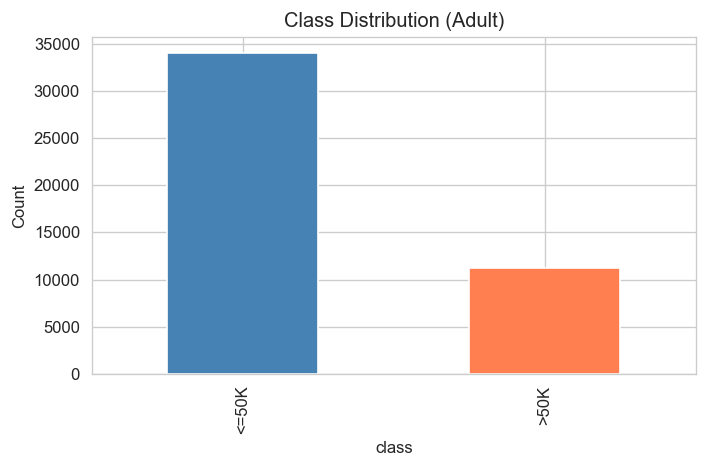

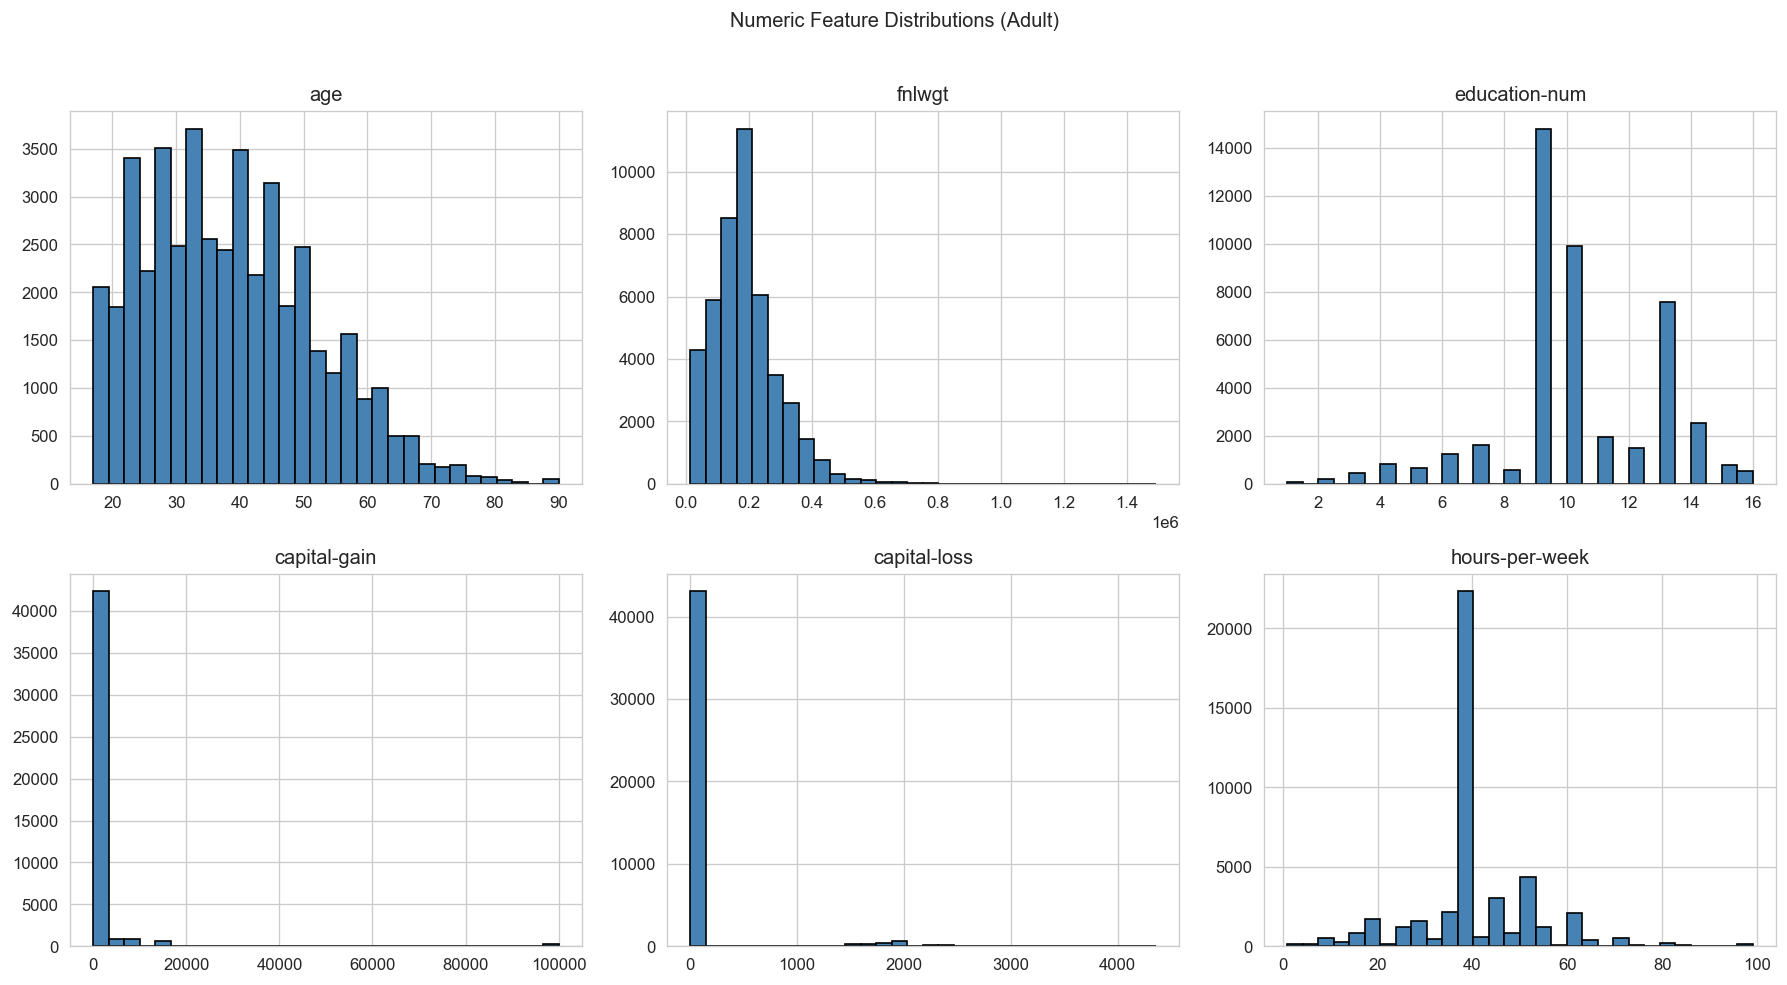

In [69]:
# Class distribution
fig, ax = plt.subplots(figsize=(6, 4))
adult['class'].value_counts().plot.bar(ax=ax, color=['steelblue', 'coral'])
ax.set_title('Class Distribution (Adult)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}eda_adult_class_dist.png', bbox_inches='tight')
plt.show()

# Numeric feature distributions
numeric_cols = adult.select_dtypes(include=[np.number]).columns.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for j, col in enumerate(numeric_cols):
    ax = axes[j // 3, j % 3]
    adult[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(col)
# Hide unused subplots
for j in range(len(numeric_cols), 6):
    axes[j // 3, j % 3].set_visible(False)
plt.suptitle('Numeric Feature Distributions (Adult)', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}eda_adult_distributions.png', bbox_inches='tight')
plt.show()

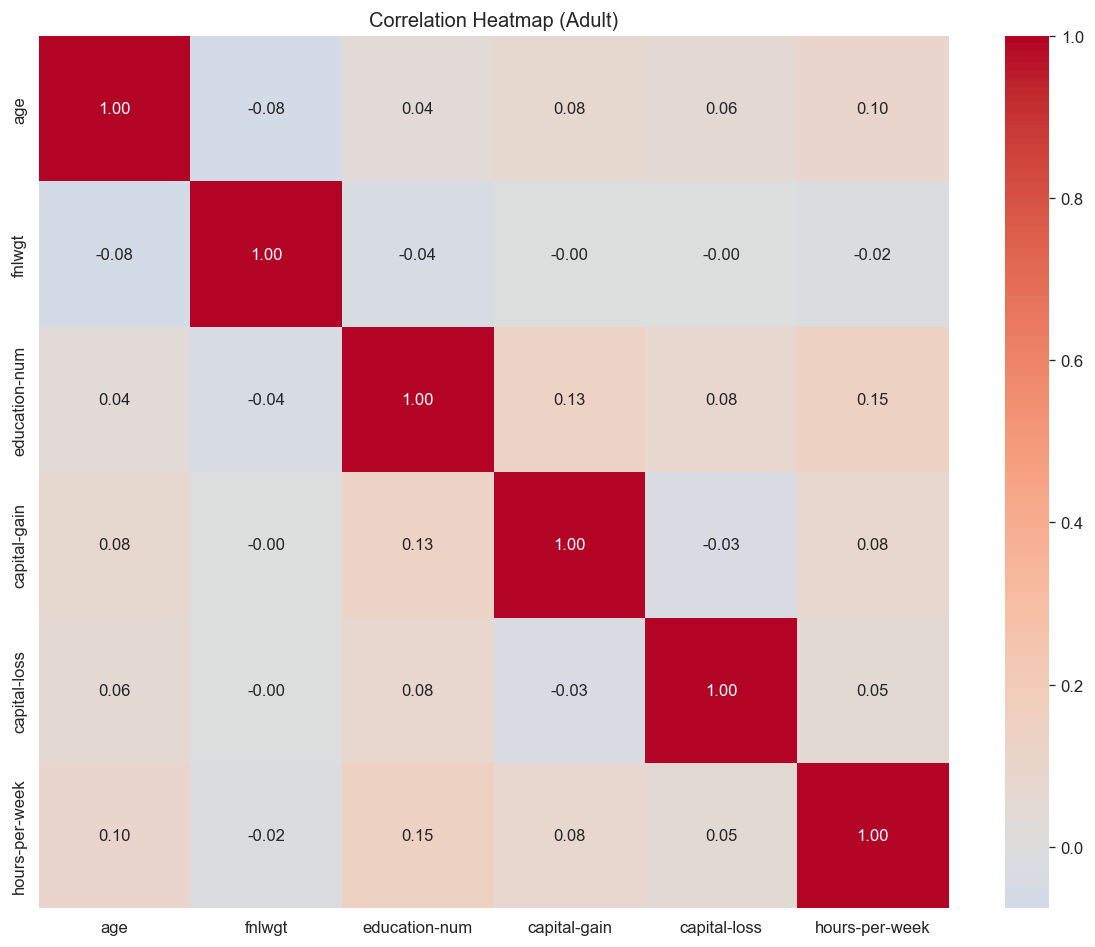

In [6]:
# Correlation heatmap for numeric features
fig, ax = plt.subplots(figsize=(10, 8))
corr = adult[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap (Adult)')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}eda_adult_correlation.png', bbox_inches='tight')
plt.show()

In [7]:
# Categorical feature cardinality
cat_cols = adult.select_dtypes(include=['object']).columns.drop('class').tolist()
print("Categorical features and unique values:")
for c in cat_cols:
    print(f"  {c}: {adult[c].nunique()} unique")

Categorical features and unique values:
  workclass: 7 unique
  education: 16 unique
  marital-status: 7 unique
  occupation: 14 unique
  relationship: 6 unique
  race: 5 unique
  sex: 2 unique
  native-country: 41 unique


## 1.2 Wine Quality Dataset

In [8]:
wine = pd.read_csv('../data/wine.csv')
print(f"Shape: {wine.shape}")
print(f"\nTarget distribution (quality):\n{wine['quality'].value_counts().sort_index()}")
print(f"\nMissing values: {wine.isnull().sum().sum()}")
print(f"\nFeature types:\n{wine.dtypes}")
wine.head()

Shape: (6497, 14)

Target distribution (quality):
quality
1      20
2     163
3    1467
4    2251
5    1561
6     813
7     204
8      18
Name: count, dtype: int64

Missing values: 0

Feature types:
fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
class                     int64
type                      int64
quality                   int64
dtype: object


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,class,type,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,5


In [9]:
wine.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,class,type,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,4.310605,0.753886,4.310605
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,1.151220,0.430779,1.151220
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,1.000000,0.000000,1.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,3.000000,1.000000,3.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,4.000000,1.000000,4.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,5.000000,1.000000,5.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,8.000000,1.000000,8.000000


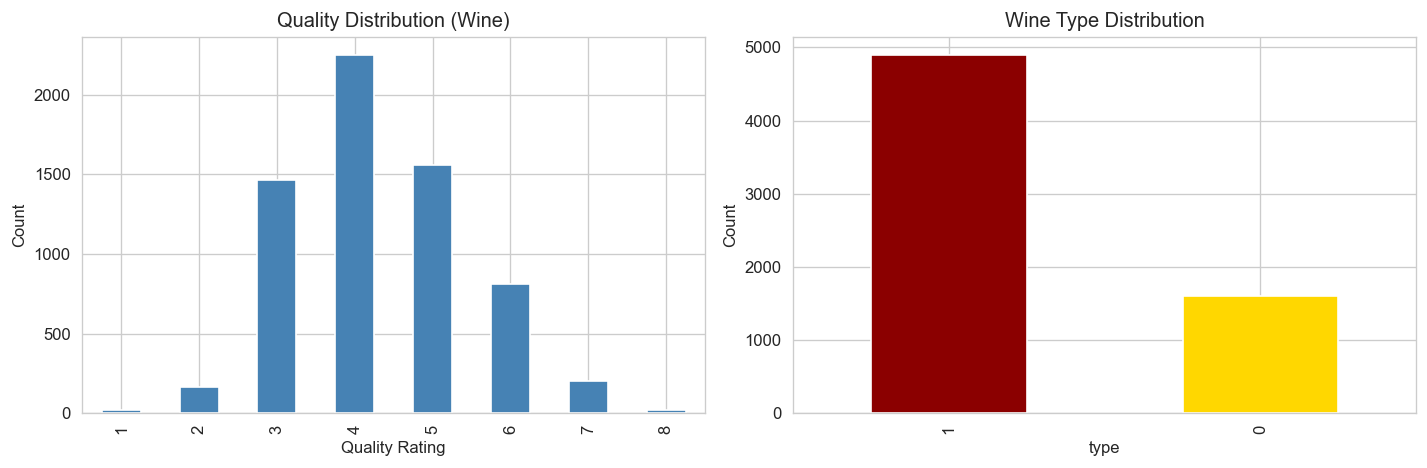

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
wine['quality'].value_counts().sort_index().plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Quality Distribution (Wine)')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Quality Rating')

# Type distribution
wine['type'].value_counts().plot.bar(ax=axes[1], color=['darkred', 'gold'])
axes[1].set_title('Wine Type Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}eda_wine_distributions.png', bbox_inches='tight')
plt.show()

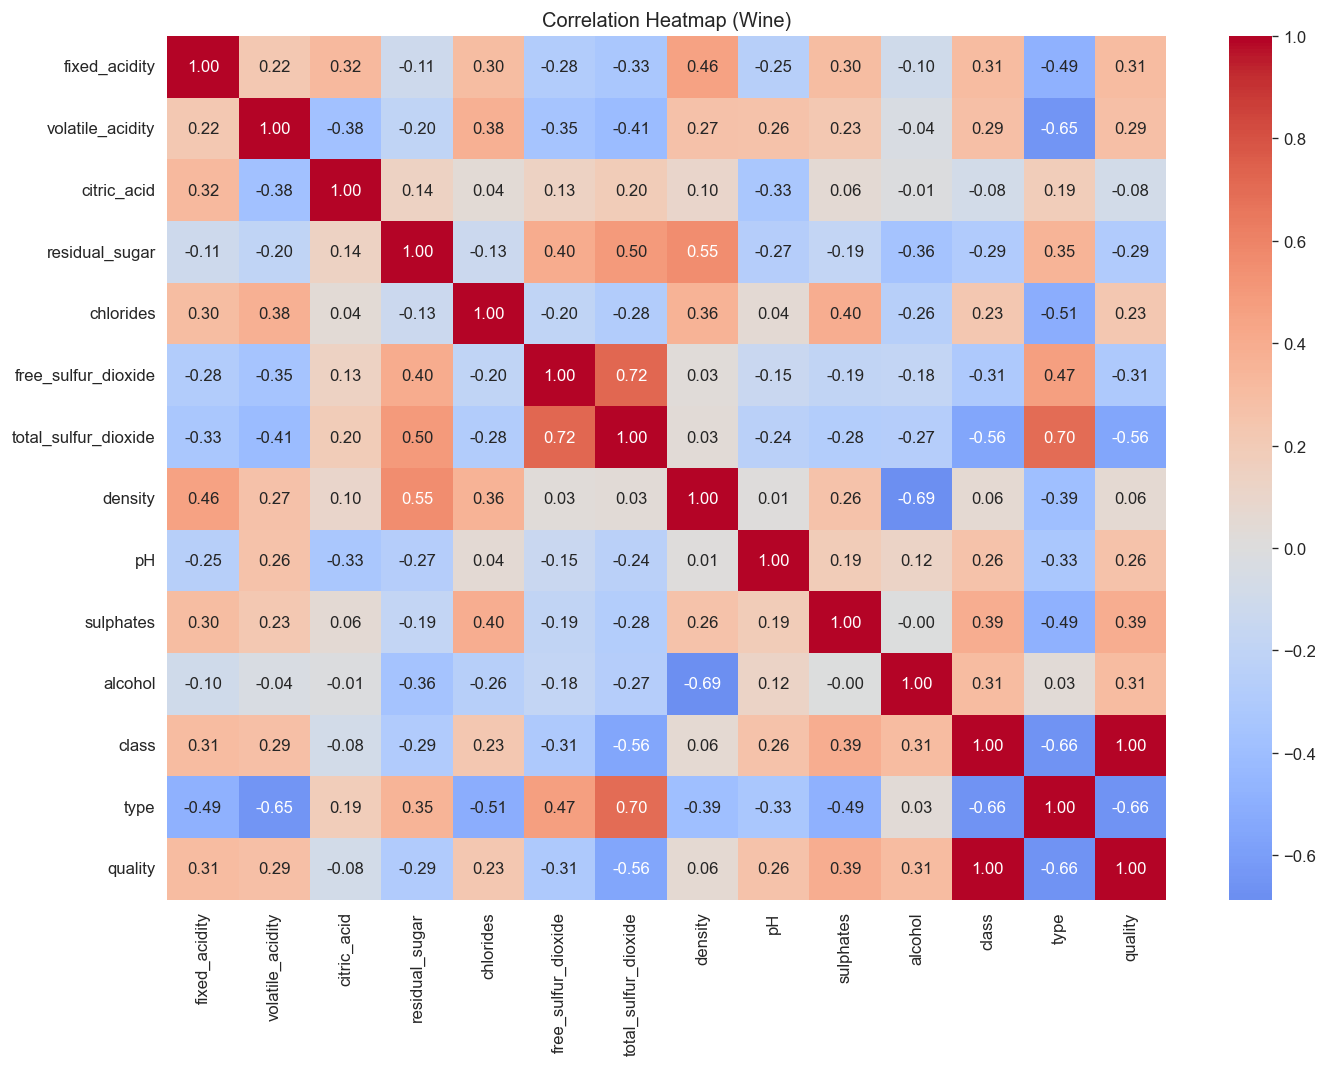

In [11]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 9))
wine_numeric = wine.select_dtypes(include=[np.number])
sns.heatmap(wine_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap (Wine)')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}eda_wine_correlation.png', bbox_inches='tight')
plt.show()

In [12]:
# Per-class sample counts — identify rare classes
print("Samples per quality class:")
for q in sorted(wine['quality'].unique()):
    n = (wine['quality'] == q).sum()
    print(f"  Quality {q}: {n} ({100*n/len(wine):.1f}%)")

Samples per quality class:
  Quality 1: 20 (0.3%)
  Quality 2: 163 (2.5%)
  Quality 3: 1467 (22.6%)
  Quality 4: 2251 (34.6%)
  Quality 5: 1561 (24.0%)
  Quality 6: 813 (12.5%)
  Quality 7: 204 (3.1%)
  Quality 8: 18 (0.3%)


## 1.3 Hypotheses

### Adult Income Dataset
**Hypothesis:** SVM (RBF) and Neural Networks will outperform Decision Trees and kNN on Adult Income because:
- After preprocessing (one-hot encoding the 8 categorical features), the original 14 features expand to 100+ columns (mostly sparse binary, plus 6 continuous), creating a high-dimensional feature space that favors margin-based classifiers (SVM).
- The ~3:1 class imbalance means models with smooth, flexible decision boundaries (RBF SVM, NN) should better capture minority-class structure than DT's axis-aligned splits or kNN's local voting, yielding higher F1.
- kNN will struggle due to the curse of dimensionality in the one-hot encoded space where Euclidean/Manhattan distances become less meaningful.
- DT may overfit on high-cardinality encoded features without aggressive pruning.

**Predicted ordering:** SVM (RBF) >= NN > DT > kNN

### Wine Quality Dataset
**Hypothesis:** Decision Trees and Neural Networks will perform best on Wine Quality because:
- All features are continuous with no missing values, and wine quality ratings are inherently ordinal — adjacent classes (e.g., 5 vs 6) will be hard to separate.
- DTs can naturally handle the multi-class problem via recursive partitioning and are robust to feature scales.
- NNs with sufficient capacity can learn non-linear interactions between chemical properties.
- SVM may struggle with the multiclass nature (requires one-vs-one/one-vs-rest decomposition) and the overlapping class boundaries.
- kNN should perform reasonably since the feature space is low-dimensional (13 features) and continuous.

**Predicted ordering:** NN >= DT > kNN > SVM

---
# 2. Preprocessing & Data Splits

In [13]:
# ===== ADULT PREPROCESSING =====
adult = pd.read_csv('../data/adult.csv')

# Encode target
adult['target'] = (adult['class'].str.strip() == '>50K').astype(int)
adult = adult.drop(columns=['class'])

# Identify feature types
cat_cols_adult = adult.select_dtypes(include=['object']).columns.tolist()
num_cols_adult = adult.select_dtypes(include=[np.number]).columns.drop('target').tolist()

print(f"Categorical features ({len(cat_cols_adult)}): {cat_cols_adult}")
print(f"Numeric features ({len(num_cols_adult)}): {num_cols_adult}")

# Preprocessing pipeline
adult_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_adult),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_adult)
    ]
)

# Split
X_adult = adult.drop(columns=['target'])
y_adult = adult['target']

X_train_adult, X_test_adult, y_train_adult, y_test_adult = train_test_split(
    X_adult, y_adult, test_size=0.2, random_state=SEED, stratify=y_adult
)

# Fit preprocessor on training data only
X_train_adult_proc = adult_preprocessor.fit_transform(X_train_adult)
X_test_adult_proc = adult_preprocessor.transform(X_test_adult)

print(f"\nAdult train shape: {X_train_adult_proc.shape}, test: {X_test_adult_proc.shape}")
print(f"Train class dist: {np.bincount(y_train_adult)}")
print(f"Test class dist:  {np.bincount(y_test_adult)}")

Categorical features (8): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Numeric features (6): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Adult train shape: (36177, 104), test: (9045, 104)
Train class dist: [27211  8966]
Test class dist:  [6803 2242]


In [14]:
# ===== WINE PREPROCESSING =====
wine = pd.read_csv('../data/wine.csv')

# Target is 'quality', 'class' column appears to be same as quality — check
print(f"quality unique: {sorted(wine['quality'].unique())}")
print(f"class unique: {sorted(wine['class'].unique())}")

# Use quality as target, drop redundant 'class' column
# Remap quality labels (3-9) to 0-indexed (0-6) for PyTorch CrossEntropyLoss
wine_label_map = {v: k for k, v in enumerate(sorted(wine['quality'].unique()))}
wine_label_unmap = {k: v for v, k in wine_label_map.items()}
y_wine = wine['quality'].map(wine_label_map)
print(f"Label mapping: {wine_label_map}")

X_wine = wine.drop(columns=['quality', 'class'])

num_cols_wine = X_wine.select_dtypes(include=[np.number]).columns.tolist()

wine_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_wine)
    ]
)

X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=SEED, stratify=y_wine
)

X_train_wine_proc = wine_preprocessor.fit_transform(X_train_wine)
X_test_wine_proc = wine_preprocessor.transform(X_test_wine)

print(f"\nWine train shape: {X_train_wine_proc.shape}, test: {X_test_wine_proc.shape}")
print(f"Train class dist: {np.bincount(y_train_wine)}")
print(f"Test class dist:  {np.bincount(y_test_wine)}")

quality unique: [1, 2, 3, 4, 5, 6, 7, 8]
class unique: [1, 2, 3, 4, 5, 6, 7, 8]
Label mapping: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7}

Wine train shape: (5197, 12), test: (1300, 12)
Train class dist: [  16  130 1174 1801 1249  650  163   14]
Test class dist:  [  4  33 293 450 312 163  41   4]


In [15]:
# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Scoring functions
f1_binary = make_scorer(f1_score, average='binary')
f1_macro = make_scorer(f1_score, average='macro')

print("CV and scoring setup complete.")

CV and scoring setup complete.


---
# 3. Helper Functions

In [16]:
def plot_learning_curve(estimator, X, y, title, scoring, cv=cv, ax=None,
                       train_sizes=np.linspace(0.1, 1.0, 6)):
    """Plot learning curve (train/val metric vs training size)."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator, X, y, train_sizes=train_sizes, cv=cv,
        scoring=scoring, n_jobs=-1, random_state=SEED
    )
    ax.plot(train_sizes_abs, train_scores.mean(axis=1), 'o-', label='Train')
    ax.fill_between(train_sizes_abs,
                    train_scores.mean(axis=1) - train_scores.std(axis=1),
                    train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1)
    ax.plot(train_sizes_abs, val_scores.mean(axis=1), 'o-', label='Validation')
    ax.fill_between(train_sizes_abs,
                    val_scores.mean(axis=1) - val_scores.std(axis=1),
                    val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1)
    ax.set_xlabel('Training Size')
    ax.set_ylabel('Score')
    ax.set_title(title)
    ax.legend(loc='best')
    return ax


def plot_validation_curve(estimator, X, y, param_name, param_range, title,
                          scoring, cv=cv, ax=None, log_scale=False):
    """Plot model-complexity curve (metric vs one hyperparameter)."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    train_scores, val_scores = validation_curve(
        estimator, X, y, param_name=param_name, param_range=param_range,
        cv=cv, scoring=scoring, n_jobs=-1
    )
    x_vals = param_range
    ax.plot(x_vals, train_scores.mean(axis=1), 'o-', label='Train')
    ax.fill_between(x_vals,
                    train_scores.mean(axis=1) - train_scores.std(axis=1),
                    train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1)
    ax.plot(x_vals, val_scores.mean(axis=1), 'o-', label='Validation')
    ax.fill_between(x_vals,
                    val_scores.mean(axis=1) - val_scores.std(axis=1),
                    val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1)
    ax.set_xlabel(param_name)
    ax.set_ylabel('Score')
    ax.set_title(title)
    if log_scale:
        ax.set_xscale('log')
    ax.legend(loc='best')
    return ax


def eval_and_time(model, X_train, y_train, X_test, y_test, model_name=''):
    """Fit model, predict, return metrics and timing."""
    t0 = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - t0

    t0 = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - t0

    acc = accuracy_score(y_test, y_pred)

    # Binary vs multiclass
    n_classes = len(np.unique(y_test))
    if n_classes == 2:
        f1 = f1_score(y_test, y_pred, average='binary')
    else:
        f1 = f1_score(y_test, y_pred, average='macro')

    return {
        'model': model_name,
        'accuracy': acc,
        'f1': f1,
        'fit_time': fit_time,
        'predict_time': pred_time,
        'y_pred': y_pred
    }


def plot_confusion(y_true, y_pred, title, ax=None, labels=None):
    """Plot confusion matrix."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)
    return ax


# Store all results
results_adult = []
results_wine = []
print("Helper functions defined.")

Helper functions defined.


---
# 4. Decision Trees

In [17]:
# ===== DT - Adult =====
dt_param_dist = {
    'max_depth': [3, 5, 8, 10, 14, 18, None],
    'min_samples_leaf': [1, 5, 10, 50, 100, 200],
    'min_samples_split': [2, 5, 10, 50, 100],
    'ccp_alpha': [0.0, 1e-4, 5e-4, 1e-3, 5e-3],
    'criterion': ['gini', 'entropy']
}

dt_adult = DecisionTreeClassifier(random_state=SEED)
dt_search_adult = RandomizedSearchCV(
    dt_adult, dt_param_dist, n_iter=60, cv=cv, scoring=f1_binary,
    random_state=SEED, n_jobs=-1
)
dt_search_adult.fit(X_train_adult_proc, y_train_adult)

print("Best DT params (Adult):", dt_search_adult.best_params_)
print(f"Best CV F1: {dt_search_adult.best_score_:.4f}")

best_dt_adult = dt_search_adult.best_estimator_
print(f"Final tree depth: {best_dt_adult.get_depth()}, leaves: {best_dt_adult.get_n_leaves()}")

Best DT params (Adult): {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 18, 'criterion': 'gini', 'ccp_alpha': 0.0001}
Best CV F1: 0.6777
Final tree depth: 18, leaves: 128


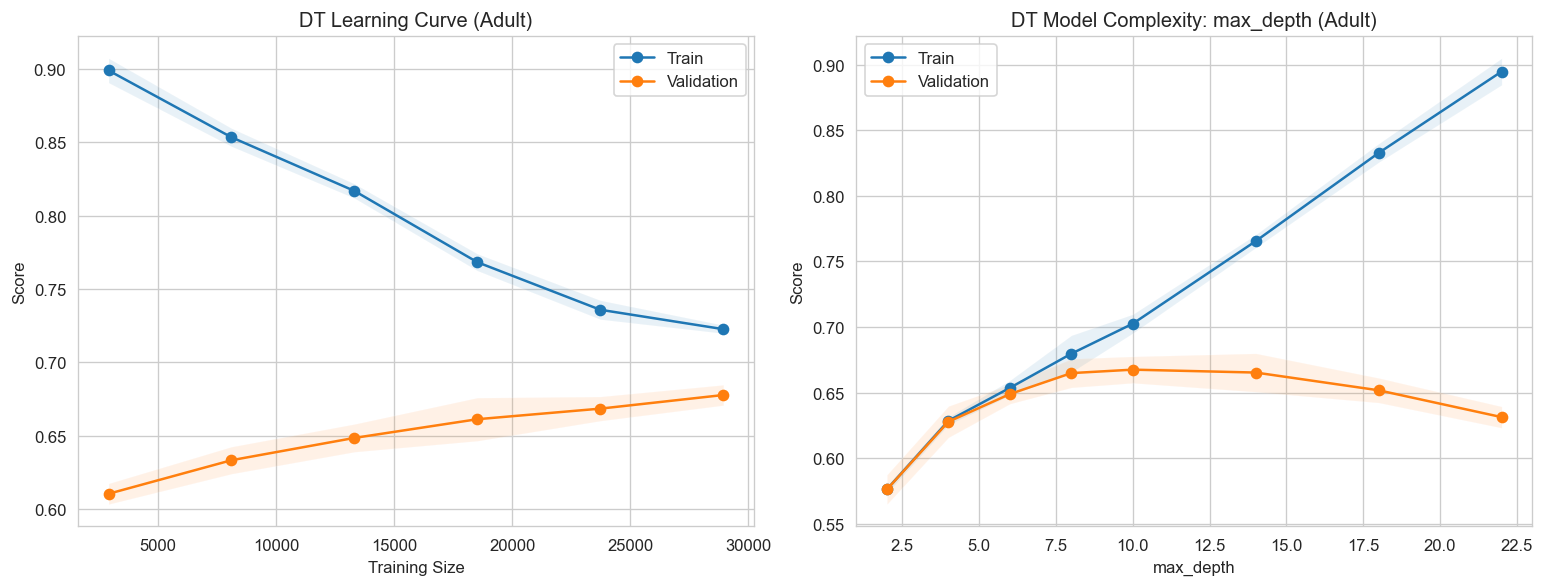

In [18]:
# DT Adult — Learning Curve + Model Complexity Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_learning_curve(best_dt_adult, X_train_adult_proc, y_train_adult,
                    'DT Learning Curve (Adult)', f1_binary, ax=axes[0])

depth_range = [2, 4, 6, 8, 10, 14, 18, 22]
plot_validation_curve(DecisionTreeClassifier(random_state=SEED),
                      X_train_adult_proc, y_train_adult,
                      'max_depth', depth_range,
                      'DT Model Complexity: max_depth (Adult)',
                      f1_binary, ax=axes[1])
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}dt_adult_curves.png', bbox_inches='tight')
plt.show()

DT Adult — Acc: 0.8541, F1: 0.6695, Fit: 0.162s, Predict: 0.001s


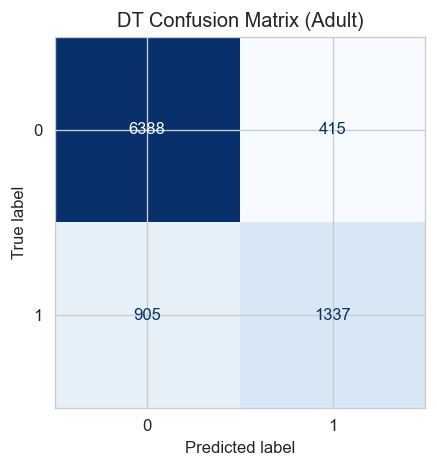

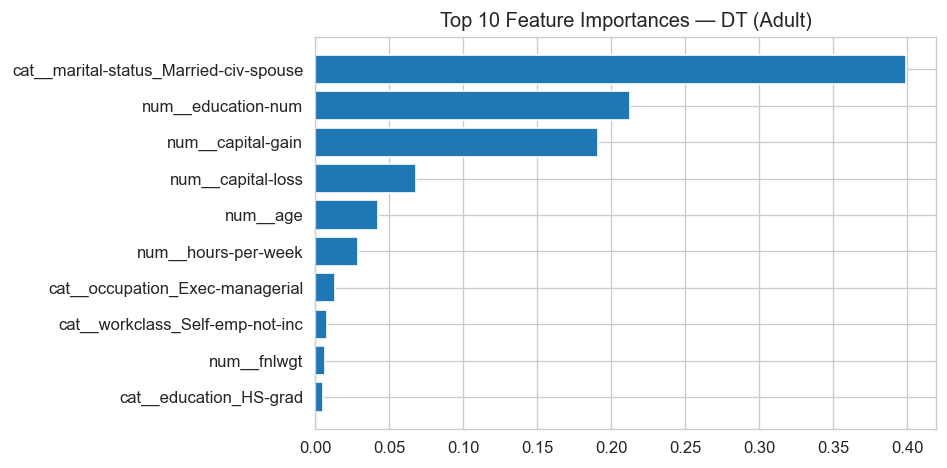

In [19]:
# DT Adult — Evaluate on test set
res = eval_and_time(best_dt_adult, X_train_adult_proc, y_train_adult,
                    X_test_adult_proc, y_test_adult, 'DT')
results_adult.append(res)
print(f"DT Adult — Acc: {res['accuracy']:.4f}, F1: {res['f1']:.4f}, "
      f"Fit: {res['fit_time']:.3f}s, Predict: {res['predict_time']:.3f}s")

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion(y_test_adult, res['y_pred'], 'DT Confusion Matrix (Adult)', ax=ax)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}dt_adult_cm.png', bbox_inches='tight')
plt.show()

# Feature importances (top 10)
feat_names = adult_preprocessor.get_feature_names_out()
importances = best_dt_adult.feature_importances_
top_idx = np.argsort(importances)[-10:]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(range(10), importances[top_idx])
ax.set_yticks(range(10))
ax.set_yticklabels(feat_names[top_idx])
ax.set_title('Top 10 Feature Importances — DT (Adult)')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}dt_adult_importances.png', bbox_inches='tight')
plt.show()

In [20]:
# ===== DT - Wine =====
dt_wine = DecisionTreeClassifier(random_state=SEED)
dt_search_wine = RandomizedSearchCV(
    dt_wine, dt_param_dist, n_iter=60, cv=cv, scoring=f1_macro,
    random_state=SEED, n_jobs=-1
)
dt_search_wine.fit(X_train_wine_proc, y_train_wine)

print("Best DT params (Wine):", dt_search_wine.best_params_)
print(f"Best CV Macro-F1: {dt_search_wine.best_score_:.4f}")

best_dt_wine = dt_search_wine.best_estimator_
print(f"Final tree depth: {best_dt_wine.get_depth()}, leaves: {best_dt_wine.get_n_leaves()}")

Best DT params (Wine): {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 14, 'criterion': 'gini', 'ccp_alpha': 0.0}
Best CV Macro-F1: 0.3933
Final tree depth: 14, leaves: 942


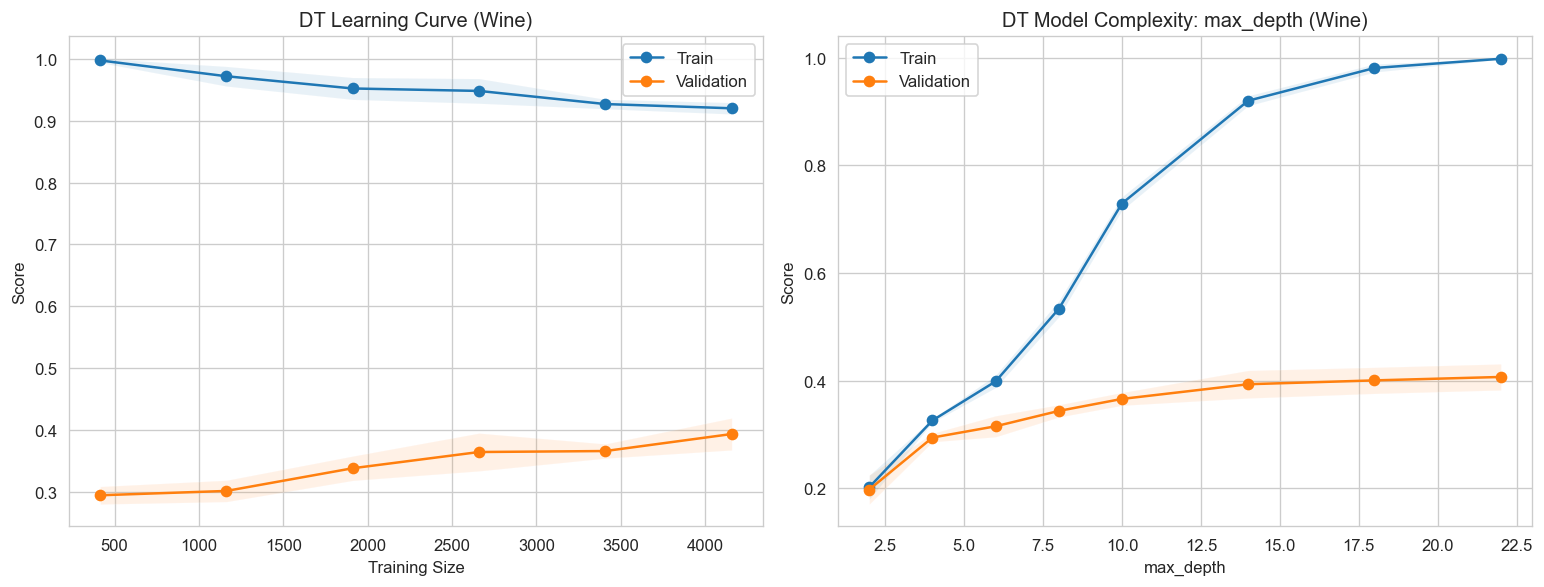

In [21]:
# DT Wine — Curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_learning_curve(best_dt_wine, X_train_wine_proc, y_train_wine,
                    'DT Learning Curve (Wine)', f1_macro, ax=axes[0])

plot_validation_curve(DecisionTreeClassifier(random_state=SEED),
                      X_train_wine_proc, y_train_wine,
                      'max_depth', depth_range,
                      'DT Model Complexity: max_depth (Wine)',
                      f1_macro, ax=axes[1])
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}dt_wine_curves.png', bbox_inches='tight')
plt.show()

DT Wine — Acc: 0.6092, F1(macro): 0.4321, Fit: 0.021s, Predict: 0.000s


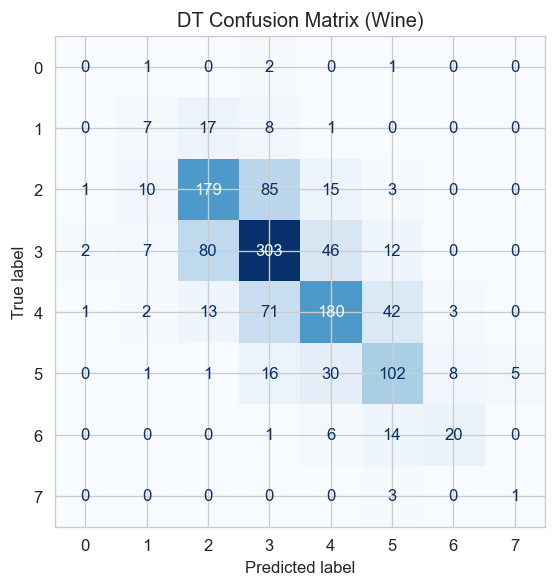

In [22]:
# DT Wine — Evaluate
res = eval_and_time(best_dt_wine, X_train_wine_proc, y_train_wine,
                    X_test_wine_proc, y_test_wine, 'DT')
results_wine.append(res)
print(f"DT Wine — Acc: {res['accuracy']:.4f}, F1(macro): {res['f1']:.4f}, "
      f"Fit: {res['fit_time']:.3f}s, Predict: {res['predict_time']:.3f}s")

fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion(y_test_wine, res['y_pred'], 'DT Confusion Matrix (Wine)', ax=ax,
               labels=list(range(len(wine_label_map))))
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}dt_wine_cm.png', bbox_inches='tight')
plt.show()

---
# 5. k-Nearest Neighbors

In [23]:
# ===== kNN - Adult =====
knn_param_dist = {
    'n_neighbors': [3, 5, 7, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['manhattan', 'euclidean']
}

knn_adult = KNeighborsClassifier()
knn_search_adult = RandomizedSearchCV(
    knn_adult, knn_param_dist, n_iter=20, cv=cv, scoring=f1_binary,
    random_state=SEED, n_jobs=-1
)
knn_search_adult.fit(X_train_adult_proc, y_train_adult)

print("Best kNN params (Adult):", knn_search_adult.best_params_)
print(f"Best CV F1: {knn_search_adult.best_score_:.4f}")
best_knn_adult = knn_search_adult.best_estimator_

Best kNN params (Adult): {'weights': 'uniform', 'n_neighbors': 21, 'metric': 'euclidean'}
Best CV F1: 0.6536


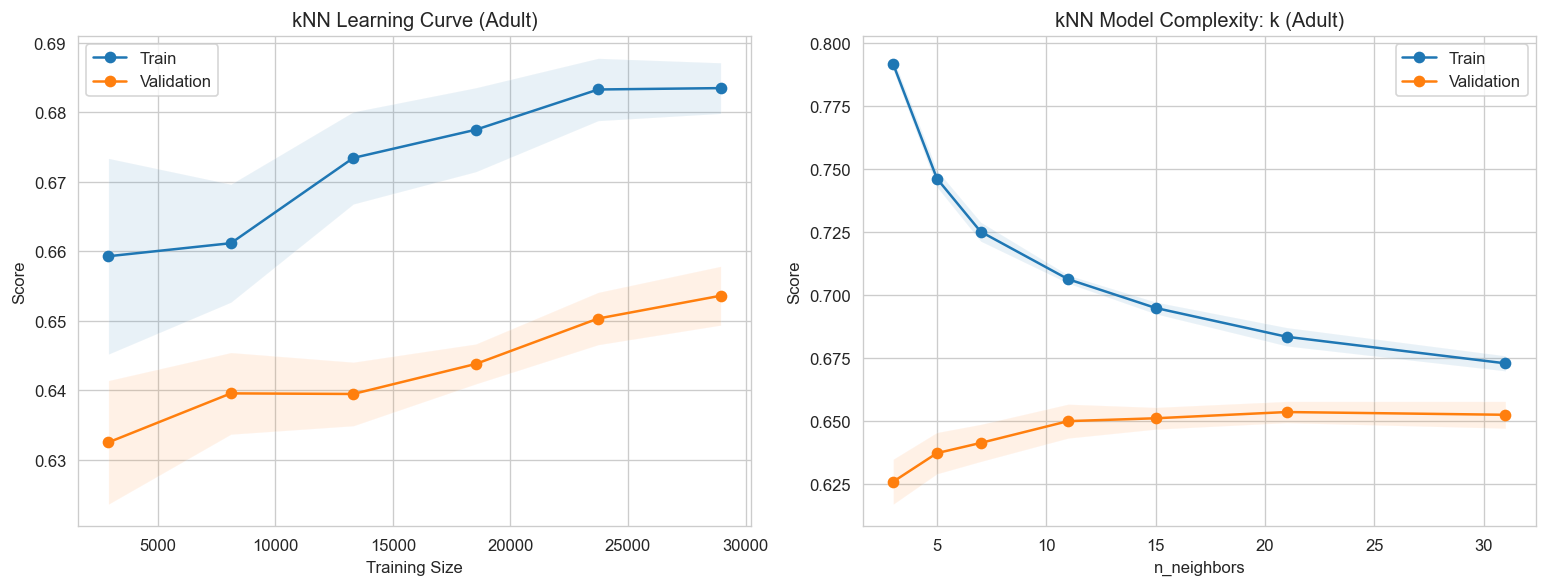

In [24]:
# kNN Adult — Curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_learning_curve(best_knn_adult, X_train_adult_proc, y_train_adult,
                    'kNN Learning Curve (Adult)', f1_binary, ax=axes[0])

k_range = [3, 5, 7, 11, 15, 21, 31]
plot_validation_curve(KNeighborsClassifier(metric=best_knn_adult.metric,
                                           weights=best_knn_adult.weights),
                      X_train_adult_proc, y_train_adult,
                      'n_neighbors', k_range,
                      'kNN Model Complexity: k (Adult)',
                      f1_binary, ax=axes[1])
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}knn_adult_curves.png', bbox_inches='tight')
plt.show()

kNN Adult — Acc: 0.8357, F1: 0.6424, Fit: 0.001s, Predict: 0.796s


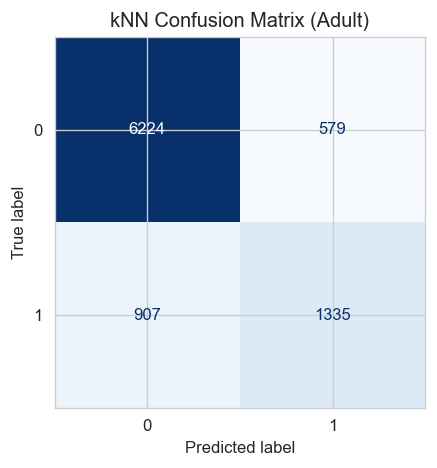

In [25]:
# kNN Adult — Evaluate
res = eval_and_time(best_knn_adult, X_train_adult_proc, y_train_adult,
                    X_test_adult_proc, y_test_adult, 'kNN')
results_adult.append(res)
print(f"kNN Adult — Acc: {res['accuracy']:.4f}, F1: {res['f1']:.4f}, "
      f"Fit: {res['fit_time']:.3f}s, Predict: {res['predict_time']:.3f}s")

fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion(y_test_adult, res['y_pred'], 'kNN Confusion Matrix (Adult)', ax=ax)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}knn_adult_cm.png', bbox_inches='tight')
plt.show()

In [26]:
# ===== kNN - Wine =====
knn_search_wine = RandomizedSearchCV(
    KNeighborsClassifier(), knn_param_dist, n_iter=20, cv=cv, scoring=f1_macro,
    random_state=SEED, n_jobs=-1
)
knn_search_wine.fit(X_train_wine_proc, y_train_wine)

print("Best kNN params (Wine):", knn_search_wine.best_params_)
print(f"Best CV Macro-F1: {knn_search_wine.best_score_:.4f}")
best_knn_wine = knn_search_wine.best_estimator_

Best kNN params (Wine): {'weights': 'distance', 'n_neighbors': 11, 'metric': 'manhattan'}
Best CV Macro-F1: 0.4546


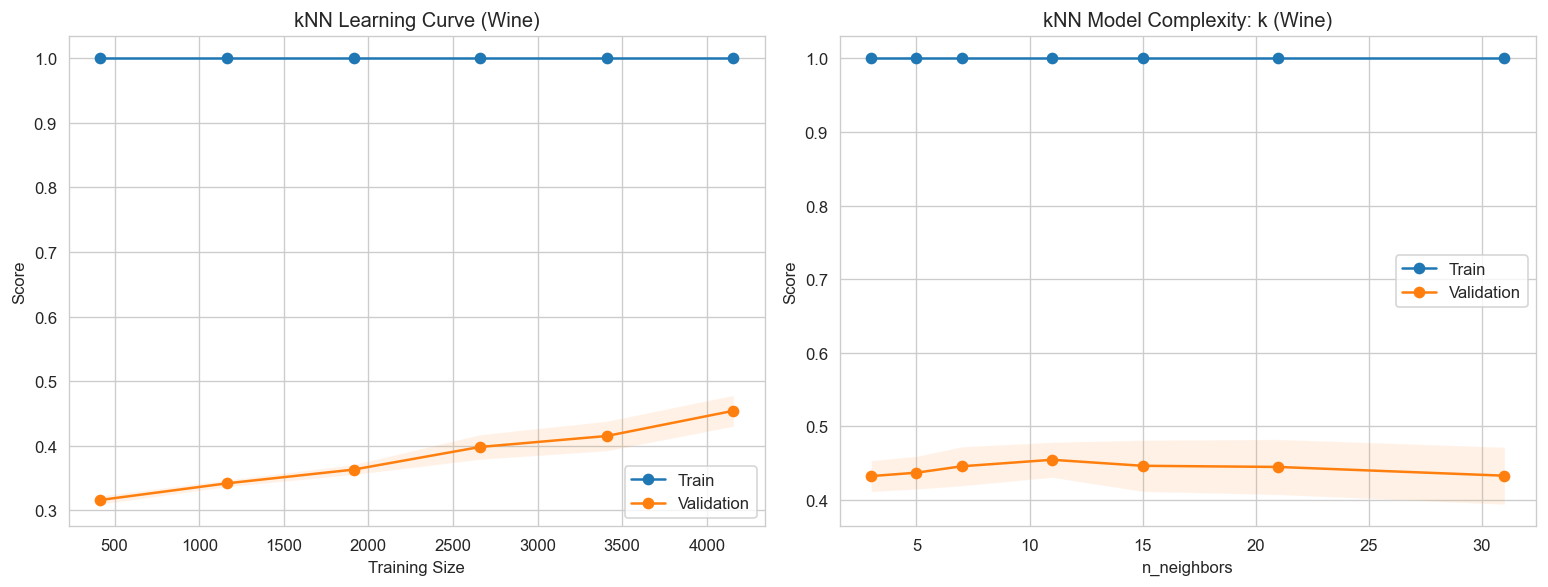

In [27]:
# kNN Wine — Curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_learning_curve(best_knn_wine, X_train_wine_proc, y_train_wine,
                    'kNN Learning Curve (Wine)', f1_macro, ax=axes[0])

plot_validation_curve(KNeighborsClassifier(metric=best_knn_wine.metric,
                                           weights=best_knn_wine.weights),
                      X_train_wine_proc, y_train_wine,
                      'n_neighbors', k_range,
                      'kNN Model Complexity: k (Wine)',
                      f1_macro, ax=axes[1])
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}knn_wine_curves.png', bbox_inches='tight')
plt.show()

kNN Wine — Acc: 0.6785, F1(macro): 0.4548, Fit: 0.001s, Predict: 0.043s


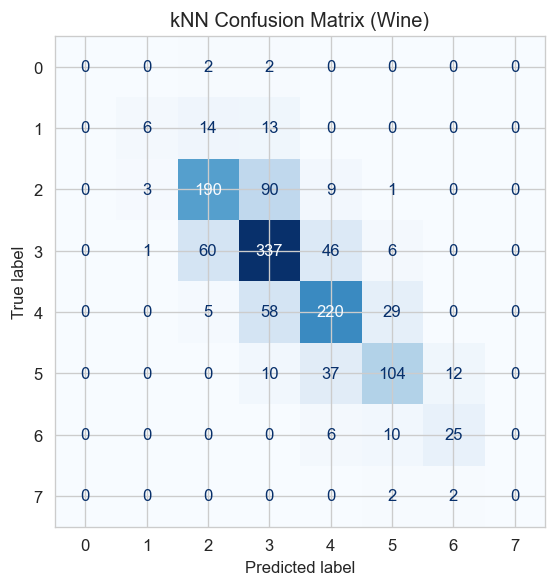

In [28]:
# kNN Wine — Evaluate
res = eval_and_time(best_knn_wine, X_train_wine_proc, y_train_wine,
                    X_test_wine_proc, y_test_wine, 'kNN')
results_wine.append(res)
print(f"kNN Wine — Acc: {res['accuracy']:.4f}, F1(macro): {res['f1']:.4f}, "
      f"Fit: {res['fit_time']:.3f}s, Predict: {res['predict_time']:.3f}s")

fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion(y_test_wine, res['y_pred'], 'kNN Confusion Matrix (Wine)', ax=ax,
               labels=list(range(len(wine_label_map))))
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}knn_wine_cm.png', bbox_inches='tight')
plt.show()

---
# 6. Support Vector Machines

In [29]:
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# ===== SVM - Adult (Linear + RBF) =====
# Linear SVM
def svm_linear_objective_adult(trial):
    C = trial.suggest_float('C', 1e-3, 100, log=True)
    model = LinearSVC(C=C, max_iter=5000, random_state=SEED, dual='auto')
    scores = cross_val_score(model, X_train_adult_proc, y_train_adult,
                             cv=cv, scoring=f1_binary, n_jobs=-1)
    return scores.mean()

study_svm_lin_adult = optuna.create_study(direction='maximize')
study_svm_lin_adult.optimize(svm_linear_objective_adult, n_trials=20)
print(f"Best Linear SVM (Adult): C={study_svm_lin_adult.best_params['C']:.4f}, F1={study_svm_lin_adult.best_value:.4f}")

best_C_lin_adult = study_svm_lin_adult.best_params['C']
best_svm_lin_adult = LinearSVC(C=best_C_lin_adult, max_iter=5000, random_state=SEED, dual='auto')

Best Linear SVM (Adult): C=2.8904, F1=0.6629


In [70]:
# RBF SVM — may need subsampling for Adult
# Use subset for tuning if needed
N_SVM_ADULT = min(10000, len(X_train_adult_proc))
idx = np.random.RandomState(SEED).choice(len(X_train_adult_proc), N_SVM_ADULT, replace=False)
X_svm_sub = X_train_adult_proc[idx]
y_svm_sub = y_train_adult.values[idx]

def svm_rbf_objective_adult(trial):
    C = trial.suggest_float('C', 1e-2, 100, log=True)
    gamma = trial.suggest_float('gamma', 1e-4, 1, log=True)
    model = SVC(C=C, gamma=gamma, kernel='rbf', random_state=SEED, max_iter=5000)
    scores = cross_val_score(model, X_svm_sub, y_svm_sub,
                             cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
                             scoring=f1_binary, n_jobs=-1)
    return scores.mean()

study_svm_rbf_adult = optuna.create_study(direction='maximize')
study_svm_rbf_adult.optimize(svm_rbf_objective_adult, n_trials=25)
print(f"Best RBF SVM (Adult): {study_svm_rbf_adult.best_params}, F1={study_svm_rbf_adult.best_value:.4f}")

bp = study_svm_rbf_adult.best_params
best_svm_rbf_adult = SVC(C=bp['C'], gamma=bp['gamma'], kernel='rbf', random_state=SEED, max_iter=5000)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxS

Best RBF SVM (Adult): {'C': 11.49857812814545, 'gamma': 0.02261843348696899}, F1=0.6604


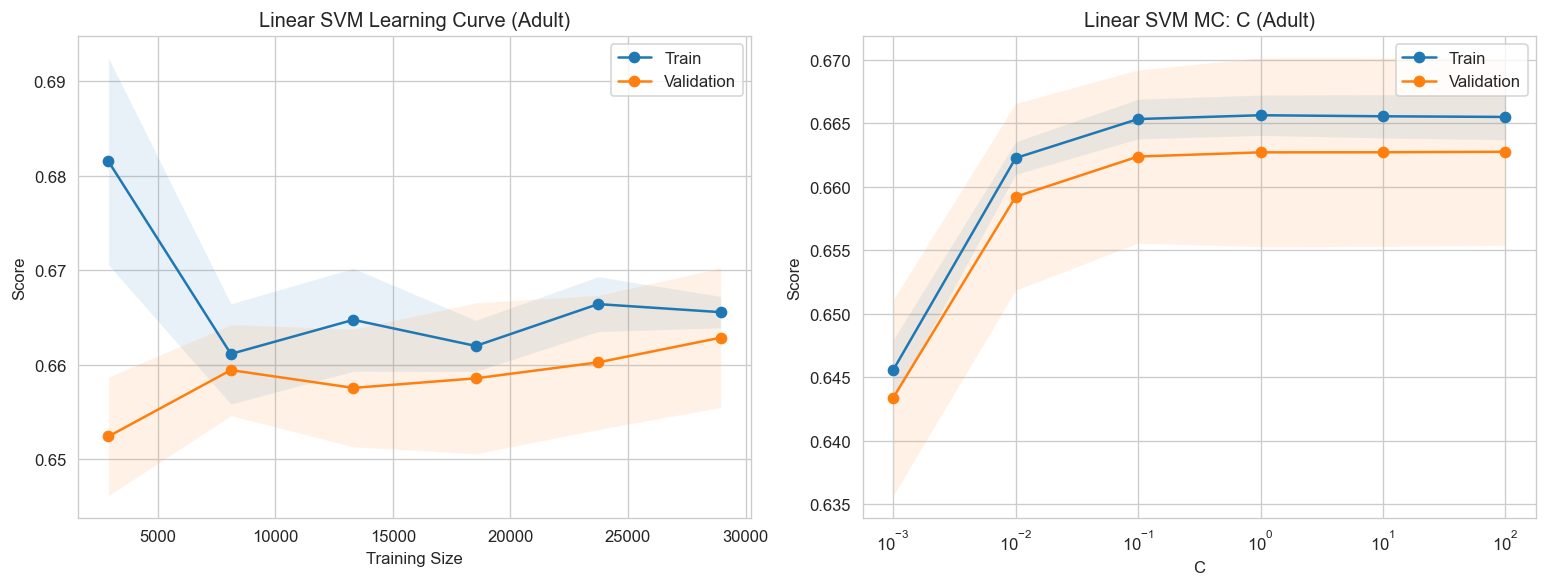

In [31]:
# SVM Adult — Learning & MC Curves (Linear)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_learning_curve(best_svm_lin_adult, X_train_adult_proc, y_train_adult,
                    'Linear SVM Learning Curve (Adult)', f1_binary, ax=axes[0])

C_range = [0.001, 0.01, 0.1, 1, 10, 100]
plot_validation_curve(LinearSVC(max_iter=5000, random_state=SEED, dual='auto'),
                      X_train_adult_proc, y_train_adult,
                      'C', C_range,
                      'Linear SVM MC: C (Adult)',
                      f1_binary, ax=axes[1], log_scale=True)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}svm_lin_adult_curves.png', bbox_inches='tight')
plt.show()

Linear SVM Adult — Acc: 0.8457, F1: 0.6543, Fit: 0.114s, Predict: 0.000s
RBF SVM Adult (10K subsample) — Acc: 0.8475, F1: 0.6496, Fit: 1.353s, Predict: 2.393s


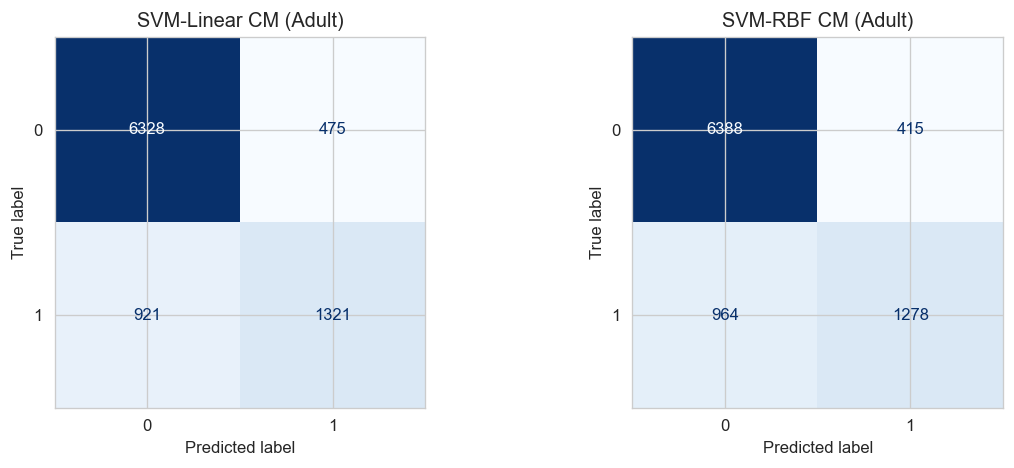

In [32]:
# SVM Adult — Evaluate both kernels
# Linear SVM on full training set (fast)
res_lin = eval_and_time(best_svm_lin_adult, X_train_adult_proc, y_train_adult,
                        X_test_adult_proc, y_test_adult, 'SVM-Linear')
results_adult.append(res_lin)

# RBF SVM on subsample (RBF is O(n^2)-O(n^3), full 36K is prohibitively slow)
res_rbf = eval_and_time(best_svm_rbf_adult, X_svm_sub, y_svm_sub,
                        X_test_adult_proc, y_test_adult, 'SVM-RBF')
results_adult.append(res_rbf)

print(f"Linear SVM Adult — Acc: {res_lin['accuracy']:.4f}, F1: {res_lin['f1']:.4f}, "
      f"Fit: {res_lin['fit_time']:.3f}s, Predict: {res_lin['predict_time']:.3f}s")
print(f"RBF SVM Adult (10K subsample) — Acc: {res_rbf['accuracy']:.4f}, F1: {res_rbf['f1']:.4f}, "
      f"Fit: {res_rbf['fit_time']:.3f}s, Predict: {res_rbf['predict_time']:.3f}s")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion(y_test_adult, res_lin['y_pred'], 'SVM-Linear CM (Adult)', ax=axes[0])
plot_confusion(y_test_adult, res_rbf['y_pred'], 'SVM-RBF CM (Adult)', ax=axes[1])
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}svm_adult_cm.png', bbox_inches='tight')
plt.show()

In [33]:
# ===== SVM - Wine =====
def svm_linear_objective_wine(trial):
    C = trial.suggest_float('C', 1e-3, 100, log=True)
    model = LinearSVC(C=C, max_iter=5000, random_state=SEED, dual='auto')
    scores = cross_val_score(model, X_train_wine_proc, y_train_wine,
                             cv=cv, scoring=f1_macro, n_jobs=-1)
    return scores.mean()

study_svm_lin_wine = optuna.create_study(direction='maximize')
study_svm_lin_wine.optimize(svm_linear_objective_wine, n_trials=20)
print(f"Best Linear SVM (Wine): C={study_svm_lin_wine.best_params['C']:.4f}, F1={study_svm_lin_wine.best_value:.4f}")

best_svm_lin_wine = LinearSVC(C=study_svm_lin_wine.best_params['C'], max_iter=5000,
                               random_state=SEED, dual='auto')

def svm_rbf_objective_wine(trial):
    C = trial.suggest_float('C', 1e-2, 100, log=True)
    gamma = trial.suggest_float('gamma', 1e-4, 1, log=True)
    model = SVC(C=C, gamma=gamma, kernel='rbf', random_state=SEED, max_iter=5000)
    scores = cross_val_score(model, X_train_wine_proc, y_train_wine,
                             cv=cv, scoring=f1_macro, n_jobs=-1)
    return scores.mean()

study_svm_rbf_wine = optuna.create_study(direction='maximize')
study_svm_rbf_wine.optimize(svm_rbf_objective_wine, n_trials=25)
bp = study_svm_rbf_wine.best_params
print(f"Best RBF SVM (Wine): {bp}, F1={study_svm_rbf_wine.best_value:.4f}")

best_svm_rbf_wine = SVC(C=bp['C'], gamma=bp['gamma'], kernel='rbf', random_state=SEED, max_iter=5000)

Best Linear SVM (Wine): C=20.4817, F1=0.2584


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxS

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxS

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxS

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxS

...

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxS

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxS

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxS

Best RBF SVM (Wine): {'C': 89.45864663925693, 'gamma': 0.5488028301012111}, F1=0.4265


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxS

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxS

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxS

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


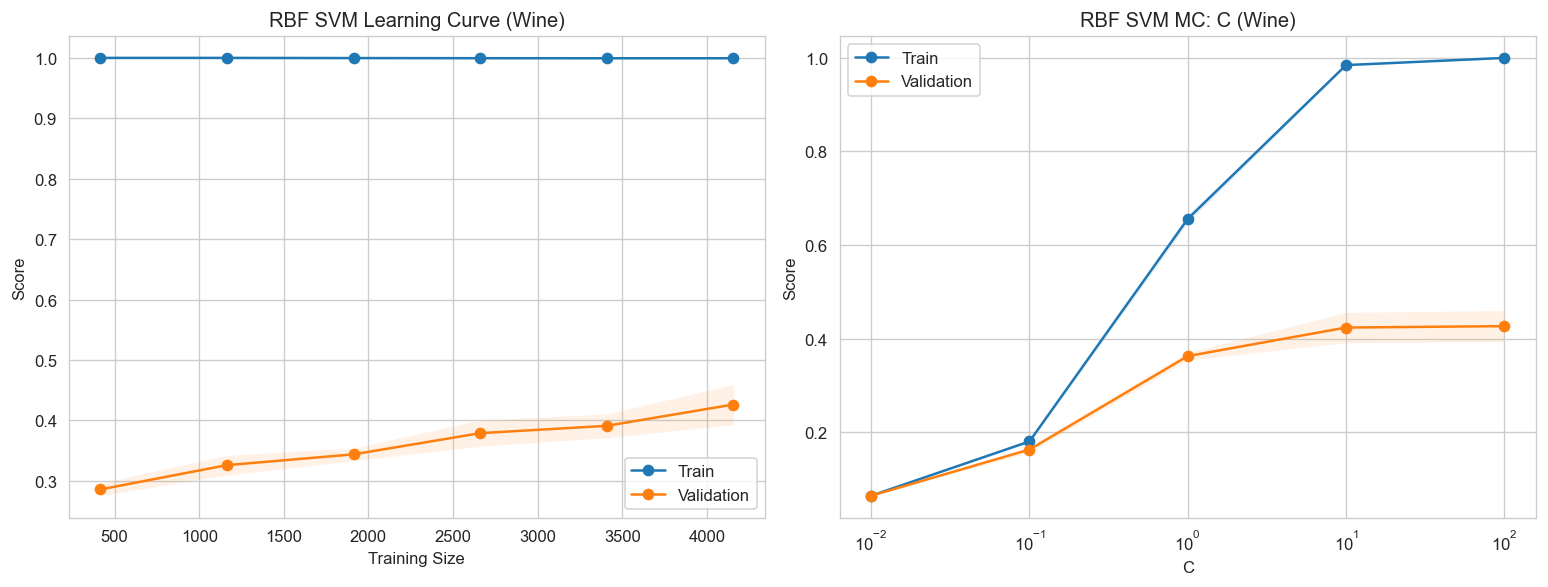

In [34]:
# SVM Wine — Curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_learning_curve(best_svm_rbf_wine, X_train_wine_proc, y_train_wine,
                    'RBF SVM Learning Curve (Wine)', f1_macro, ax=axes[0])

C_range = [0.01, 0.1, 1, 10, 100]
plot_validation_curve(SVC(kernel='rbf', gamma=bp['gamma'], random_state=SEED, max_iter=5000),
                      X_train_wine_proc, y_train_wine,
                      'C', C_range, 'RBF SVM MC: C (Wine)',
                      f1_macro, ax=axes[1], log_scale=True)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}svm_wine_curves.png', bbox_inches='tight')
plt.show()

Linear SVM Wine — Acc: 0.5177, F1(macro): 0.2526
RBF SVM Wine    — Acc: 0.6615, F1(macro): 0.4665


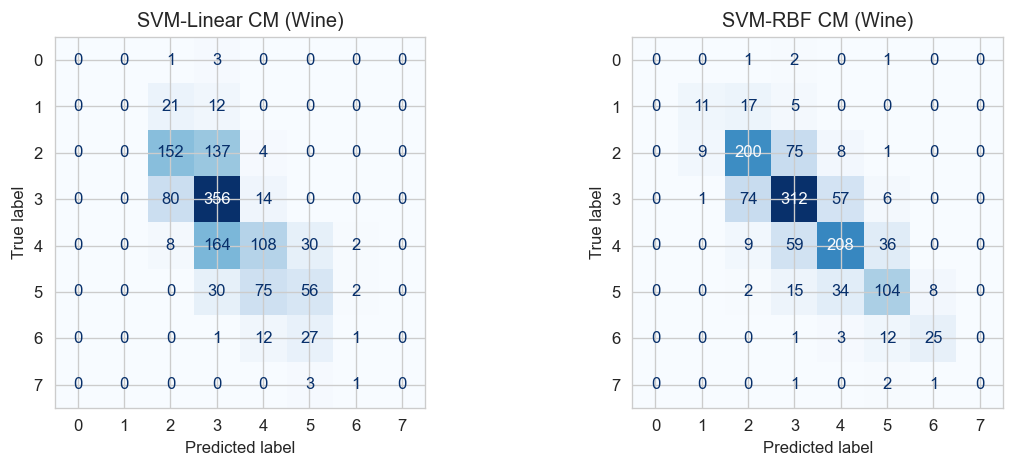

In [35]:
# SVM Wine — Evaluate
res_lin = eval_and_time(best_svm_lin_wine, X_train_wine_proc, y_train_wine,
                        X_test_wine_proc, y_test_wine, 'SVM-Linear')
results_wine.append(res_lin)

res_rbf = eval_and_time(best_svm_rbf_wine, X_train_wine_proc, y_train_wine,
                        X_test_wine_proc, y_test_wine, 'SVM-RBF')
results_wine.append(res_rbf)

print(f"Linear SVM Wine — Acc: {res_lin['accuracy']:.4f}, F1(macro): {res_lin['f1']:.4f}")
print(f"RBF SVM Wine    — Acc: {res_rbf['accuracy']:.4f}, F1(macro): {res_rbf['f1']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion(y_test_wine, res_lin['y_pred'], 'SVM-Linear CM (Wine)', ax=axes[0],
               labels=list(range(len(wine_label_map))))
plot_confusion(y_test_wine, res_rbf['y_pred'], 'SVM-RBF CM (Wine)', ax=axes[1],
               labels=list(range(len(wine_label_map))))
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}svm_wine_cm.png', bbox_inches='tight')
plt.show()

---
# 7. Neural Networks — scikit-learn (MLPClassifier, SGD)

In [36]:
# ===== NN sklearn - Adult =====
def nn_sklearn_objective_adult(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    layer_size = trial.suggest_int('layer_size', 32, 256)
    hidden = tuple([layer_size] * n_layers)
    alpha = trial.suggest_float('alpha', 1e-5, 1e-1, log=True)
    lr_init = trial.suggest_float('learning_rate_init', 1e-4, 0.1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256, 512])

    model = MLPClassifier(
        hidden_layer_sizes=hidden, solver='sgd', alpha=alpha,
        learning_rate_init=lr_init, batch_size=batch_size,
        max_iter=200, early_stopping=True, validation_fraction=0.15,
        random_state=SEED, momentum=0, nesterovs_momentum=False
    )
    scores = cross_val_score(model, X_train_adult_proc, y_train_adult,
                             cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
                             scoring=f1_binary, n_jobs=-1)
    return scores.mean()

study_nn_sk_adult = optuna.create_study(direction='maximize')
study_nn_sk_adult.optimize(nn_sklearn_objective_adult, n_trials=30)
bp = study_nn_sk_adult.best_params
print(f"Best NN sklearn (Adult): {bp}, F1={study_nn_sk_adult.best_value:.4f}")

hidden_adult = tuple([bp['layer_size']] * bp['n_layers'])
best_nn_sk_adult = MLPClassifier(
    hidden_layer_sizes=hidden_adult, solver='sgd', alpha=bp['alpha'],
    learning_rate_init=bp['learning_rate_init'], batch_size=bp['batch_size'],
    max_iter=300, early_stopping=True, validation_fraction=0.15,
    random_state=SEED, momentum=0, nesterovs_momentum=False
)

Best NN sklearn (Adult): {'n_layers': 1, 'layer_size': 157, 'alpha': 0.0004018632568213544, 'learning_rate_init': 0.05236655562551775, 'batch_size': 128}, F1=0.6859


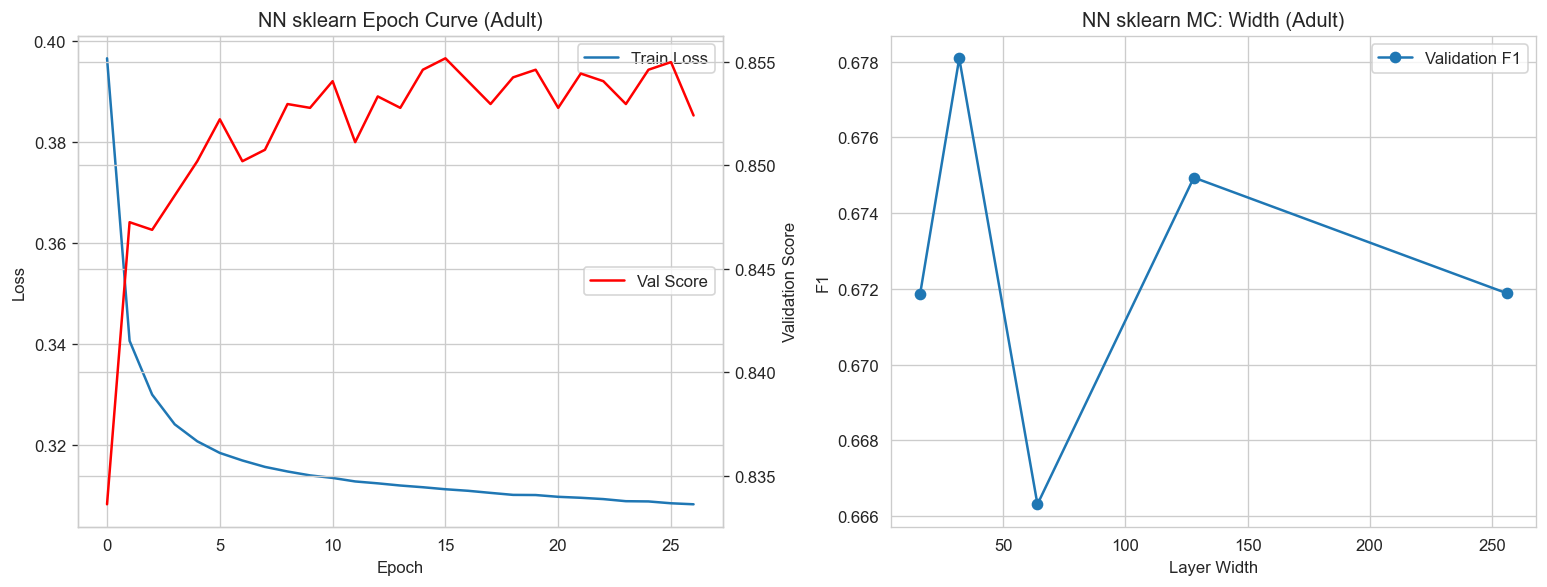

In [37]:
# NN sklearn Adult — Fit and get epoch curves
best_nn_sk_adult.fit(X_train_adult_proc, y_train_adult)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Epoch curve (loss)
axes[0].plot(best_nn_sk_adult.loss_curve_, label='Train Loss')
if hasattr(best_nn_sk_adult, 'validation_scores_') and best_nn_sk_adult.validation_scores_:
    ax2 = axes[0].twinx()
    ax2.plot(best_nn_sk_adult.validation_scores_, 'r-', label='Val Score')
    ax2.set_ylabel('Validation Score')
    ax2.legend(loc='center right')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('NN sklearn Epoch Curve (Adult)')
axes[0].legend(loc='upper right')

# MC curve: vary width
widths = [16, 32, 64, 128, 256]
mc_train, mc_val = [], []
for w in widths:
    m = MLPClassifier(hidden_layer_sizes=(w,)*bp['n_layers'], solver='sgd',
                      alpha=bp['alpha'], learning_rate_init=bp['learning_rate_init'],
                      batch_size=bp['batch_size'], max_iter=200, early_stopping=True,
                      validation_fraction=0.15, random_state=SEED,
                      momentum=0, nesterovs_momentum=False)
    sc = cross_val_score(m, X_train_adult_proc, y_train_adult,
                         cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
                         scoring=f1_binary, n_jobs=-1)
    mc_val.append(sc.mean())
axes[1].plot(widths, mc_val, 'o-', label='Validation F1')
axes[1].set_xlabel('Layer Width')
axes[1].set_ylabel('F1')
axes[1].set_title('NN sklearn MC: Width (Adult)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}nn_sklearn_adult_curves.png', bbox_inches='tight')
plt.show()

NN sklearn Adult — Acc: 0.8503, F1: 0.6805


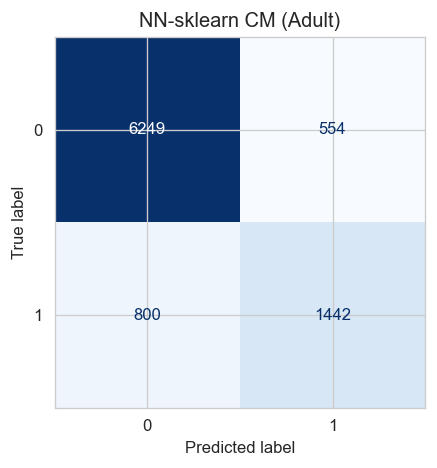

In [38]:
# NN sklearn Adult — Evaluate
res = eval_and_time(
    MLPClassifier(hidden_layer_sizes=hidden_adult, solver='sgd', alpha=bp['alpha'],
                  learning_rate_init=bp['learning_rate_init'], batch_size=bp['batch_size'],
                  max_iter=300, early_stopping=True, validation_fraction=0.15,
                  random_state=SEED, momentum=0, nesterovs_momentum=False),
    X_train_adult_proc, y_train_adult, X_test_adult_proc, y_test_adult, 'NN-sklearn')
results_adult.append(res)
print(f"NN sklearn Adult — Acc: {res['accuracy']:.4f}, F1: {res['f1']:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion(y_test_adult, res['y_pred'], 'NN-sklearn CM (Adult)', ax=ax)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}nn_sklearn_adult_cm.png', bbox_inches='tight')
plt.show()

In [39]:
# ===== NN sklearn - Wine =====
def nn_sklearn_objective_wine(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    layer_size = trial.suggest_int('layer_size', 32, 256)
    hidden = tuple([layer_size] * n_layers)
    alpha = trial.suggest_float('alpha', 1e-5, 1e-1, log=True)
    lr_init = trial.suggest_float('learning_rate_init', 1e-4, 0.1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])

    model = MLPClassifier(
        hidden_layer_sizes=hidden, solver='sgd', alpha=alpha,
        learning_rate_init=lr_init, batch_size=batch_size,
        max_iter=200, early_stopping=True, validation_fraction=0.15,
        random_state=SEED, momentum=0, nesterovs_momentum=False
    )
    scores = cross_val_score(model, X_train_wine_proc, y_train_wine,
                             cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
                             scoring=f1_macro, n_jobs=-1)
    return scores.mean()

study_nn_sk_wine = optuna.create_study(direction='maximize')
study_nn_sk_wine.optimize(nn_sklearn_objective_wine, n_trials=30)
bp_wine = study_nn_sk_wine.best_params
print(f"Best NN sklearn (Wine): {bp_wine}, F1={study_nn_sk_wine.best_value:.4f}")

hidden_wine = tuple([bp_wine['layer_size']] * bp_wine['n_layers'])
best_nn_sk_wine = MLPClassifier(
    hidden_layer_sizes=hidden_wine, solver='sgd', alpha=bp_wine['alpha'],
    learning_rate_init=bp_wine['learning_rate_init'], batch_size=bp_wine['batch_size'],
    max_iter=300, early_stopping=True, validation_fraction=0.15,
    random_state=SEED, momentum=0, nesterovs_momentum=False
)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Best NN sklearn (Wine): {'n_layers': 3, 'layer_size': 63, 'alpha': 0.003173842764716055, 'learning_rate_init': 0.04348209428566568, 'batch_size': 64}, F1=0.3240


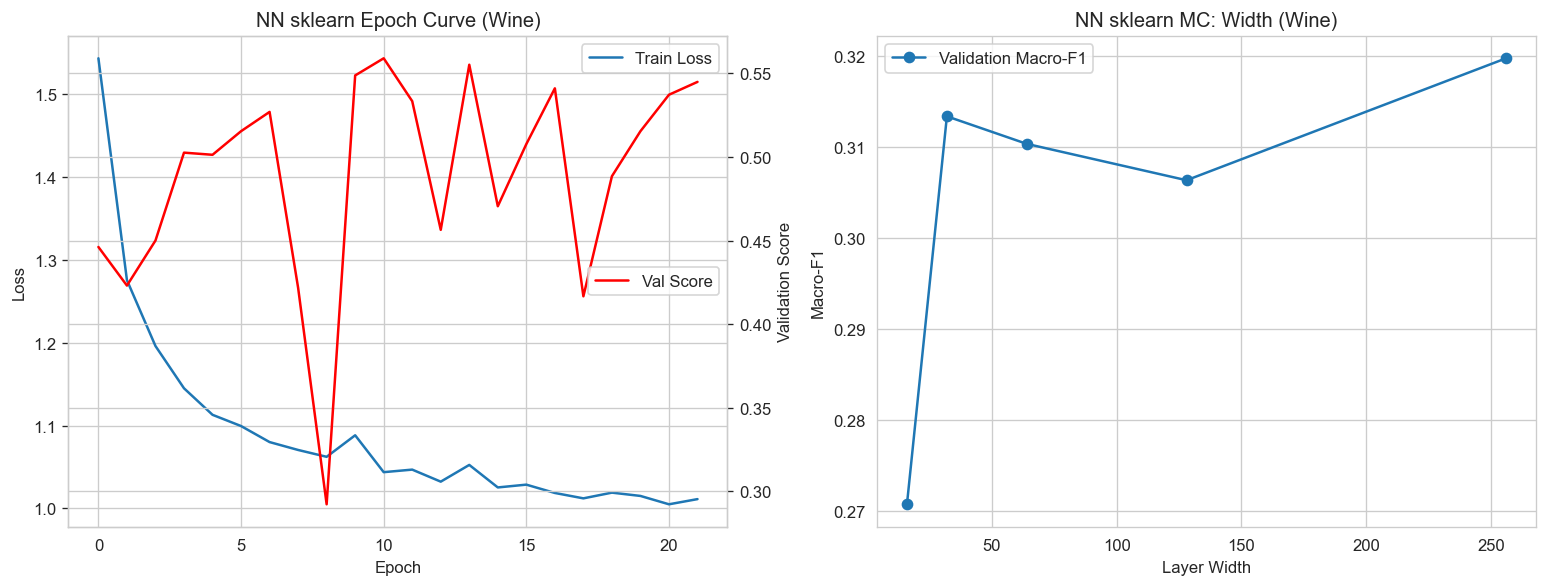

In [40]:
# NN sklearn Wine — Epoch + MC curves
best_nn_sk_wine.fit(X_train_wine_proc, y_train_wine)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(best_nn_sk_wine.loss_curve_, label='Train Loss')
if hasattr(best_nn_sk_wine, 'validation_scores_') and best_nn_sk_wine.validation_scores_:
    ax2 = axes[0].twinx()
    ax2.plot(best_nn_sk_wine.validation_scores_, 'r-', label='Val Score')
    ax2.set_ylabel('Validation Score')
    ax2.legend(loc='center right')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('NN sklearn Epoch Curve (Wine)')
axes[0].legend()

widths = [16, 32, 64, 128, 256]
mc_val = []
for w in widths:
    m = MLPClassifier(hidden_layer_sizes=(w,)*bp_wine['n_layers'], solver='sgd',
                      alpha=bp_wine['alpha'], learning_rate_init=bp_wine['learning_rate_init'],
                      batch_size=bp_wine['batch_size'], max_iter=200, early_stopping=True,
                      validation_fraction=0.15, random_state=SEED,
                      momentum=0, nesterovs_momentum=False)
    sc = cross_val_score(m, X_train_wine_proc, y_train_wine,
                         cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
                         scoring=f1_macro, n_jobs=-1)
    mc_val.append(sc.mean())
axes[1].plot(widths, mc_val, 'o-', label='Validation Macro-F1')
axes[1].set_xlabel('Layer Width')
axes[1].set_ylabel('Macro-F1')
axes[1].set_title('NN sklearn MC: Width (Wine)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}nn_sklearn_wine_curves.png', bbox_inches='tight')
plt.show()

NN sklearn Wine — Acc: 0.5346, F1(macro): 0.2846


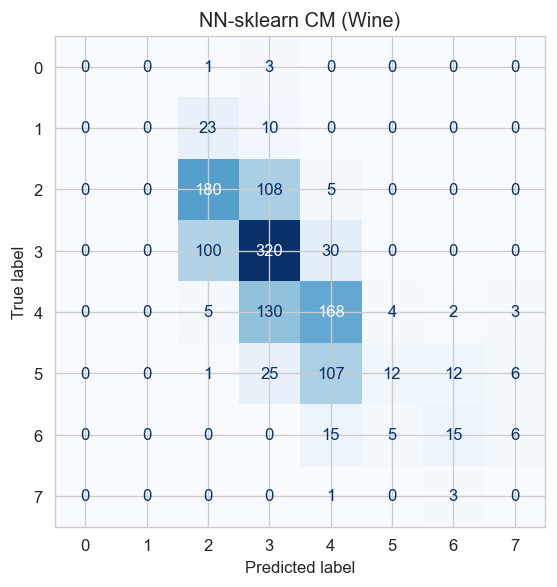

In [41]:
# NN sklearn Wine — Evaluate
res = eval_and_time(
    MLPClassifier(hidden_layer_sizes=hidden_wine, solver='sgd', alpha=bp_wine['alpha'],
                  learning_rate_init=bp_wine['learning_rate_init'], batch_size=bp_wine['batch_size'],
                  max_iter=300, early_stopping=True, validation_fraction=0.15,
                  random_state=SEED, momentum=0, nesterovs_momentum=False),
    X_train_wine_proc, y_train_wine, X_test_wine_proc, y_test_wine, 'NN-sklearn')
results_wine.append(res)
print(f"NN sklearn Wine — Acc: {res['accuracy']:.4f}, F1(macro): {res['f1']:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion(y_test_wine, res['y_pred'], 'NN-sklearn CM (Wine)', ax=ax,
               labels=list(range(len(wine_label_map))))
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}nn_sklearn_wine_cm.png', bbox_inches='tight')
plt.show()

---
# 8. Neural Networks — PyTorch (SGD only)

In [42]:
# PyTorch MLP definition
class PytorchMLP(nn.Module):
    def __init__(self, input_dim, hidden_sizes, output_dim, activation='relu', dropout=0.2):
        super().__init__()
        layers = []
        prev = input_dim
        act_fn = {'relu': nn.ReLU, 'gelu': nn.GELU, 'silu': nn.SiLU, 'tanh': nn.Tanh}
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(act_fn.get(activation, nn.ReLU)())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def train_pytorch_mlp(model, X_train, y_train, X_val, y_val, lr=0.01, weight_decay=1e-4,
                      batch_size=256, max_epochs=100, patience=10, task='binary'):
    """Train PyTorch MLP with SGD only (no momentum). Returns epoch history."""
    device = torch.device('cpu')
    model = model.to(device)

    X_tr = torch.FloatTensor(X_train).to(device)
    X_v = torch.FloatTensor(X_val).to(device)

    if task == 'binary':
        y_tr = torch.FloatTensor(y_train.values if hasattr(y_train, 'values') else y_train).to(device)
        y_v = torch.FloatTensor(y_val.values if hasattr(y_val, 'values') else y_val).to(device)
        criterion = nn.BCEWithLogitsLoss()
    else:
        y_tr = torch.LongTensor(y_train.values if hasattr(y_train, 'values') else y_train).to(device)
        y_v = torch.LongTensor(y_val.values if hasattr(y_val, 'values') else y_val).to(device)
        criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay, momentum=0)
    dataset = torch.utils.data.TensorDataset(X_tr, y_tr)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    history = {'train_loss': [], 'val_loss': [], 'train_metric': [], 'val_metric': []}
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None

    for epoch in range(max_epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            optimizer.zero_grad()
            out = model(xb)
            if task == 'binary':
                loss = criterion(out.squeeze(), yb)
            else:
                loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        epoch_loss /= len(X_tr)
        history['train_loss'].append(epoch_loss)

        # Validation
        model.eval()
        with torch.no_grad():
            v_out = model(X_v)
            if task == 'binary':
                v_loss = criterion(v_out.squeeze(), y_v).item()
                v_pred = (torch.sigmoid(v_out.squeeze()) > 0.5).cpu().numpy()
                t_out = model(X_tr)
                t_pred = (torch.sigmoid(t_out.squeeze()) > 0.5).cpu().numpy()
                v_f1 = f1_score(y_v.cpu().numpy(), v_pred)
                t_f1 = f1_score(y_tr.cpu().numpy(), t_pred)
            else:
                v_loss = criterion(v_out, y_v).item()
                v_pred = v_out.argmax(dim=1).cpu().numpy()
                t_out = model(X_tr)
                t_pred = t_out.argmax(dim=1).cpu().numpy()
                v_f1 = f1_score(y_v.cpu().numpy(), v_pred, average='macro')
                t_f1 = f1_score(y_tr.cpu().numpy(), t_pred, average='macro')

        history['val_loss'].append(v_loss)
        history['train_metric'].append(t_f1)
        history['val_metric'].append(v_f1)

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_state:
        model.load_state_dict(best_state)
    return model, history


def predict_pytorch(model, X, task='binary'):
    model.eval()
    with torch.no_grad():
        out = model(torch.FloatTensor(X))
        if task == 'binary':
            return (torch.sigmoid(out.squeeze()) > 0.5).numpy().astype(int)
        else:
            return out.argmax(dim=1).numpy()

print("PyTorch MLP utilities defined.")

PyTorch MLP utilities defined.


In [43]:
# ===== PyTorch NN - Adult =====
# Split training into train/val for epoch curves
from sklearn.model_selection import train_test_split as tts
X_tr_a, X_val_a, y_tr_a, y_val_a = tts(
    X_train_adult_proc, y_train_adult, test_size=0.15, random_state=SEED, stratify=y_train_adult
)

input_dim_adult = X_train_adult_proc.shape[1]

# Architecture comparison: shallow-wide vs deep-narrow (similar param count)
# Shallow: 2 layers of ~200 => ~200*input + 200*200 + 200*1
# Deep: 4 layers of ~100 => ~100*input + 100*100*3 + 100*1

shallow_adult = PytorchMLP(input_dim_adult, [200, 200], 1, activation='relu', dropout=0.2)
deep_adult = PytorchMLP(input_dim_adult, [100, 100, 100, 100], 1, activation='relu', dropout=0.2)

print(f"Shallow params: {shallow_adult.count_params()}")
print(f"Deep params: {deep_adult.count_params()}")

# Train shallow
t0 = time.time()
shallow_adult, hist_shallow_a = train_pytorch_mlp(
    shallow_adult, X_tr_a, y_tr_a, X_val_a, y_val_a,
    lr=0.01, weight_decay=1e-4, batch_size=256, max_epochs=100, patience=15, task='binary'
)
shallow_fit_time_a = time.time() - t0

# Train deep
t0 = time.time()
deep_adult, hist_deep_a = train_pytorch_mlp(
    deep_adult, X_tr_a, y_tr_a, X_val_a, y_val_a,
    lr=0.01, weight_decay=1e-4, batch_size=256, max_epochs=100, patience=15, task='binary'
)
deep_fit_time_a = time.time() - t0

print(f"Shallow trained {len(hist_shallow_a['train_loss'])} epochs in {shallow_fit_time_a:.1f}s")
print(f"Deep trained {len(hist_deep_a['train_loss'])} epochs in {deep_fit_time_a:.1f}s")

Shallow params: 61401
Deep params: 40901


Shallow trained 100 epochs in 31.1s
Deep trained 100 epochs in 21.4s


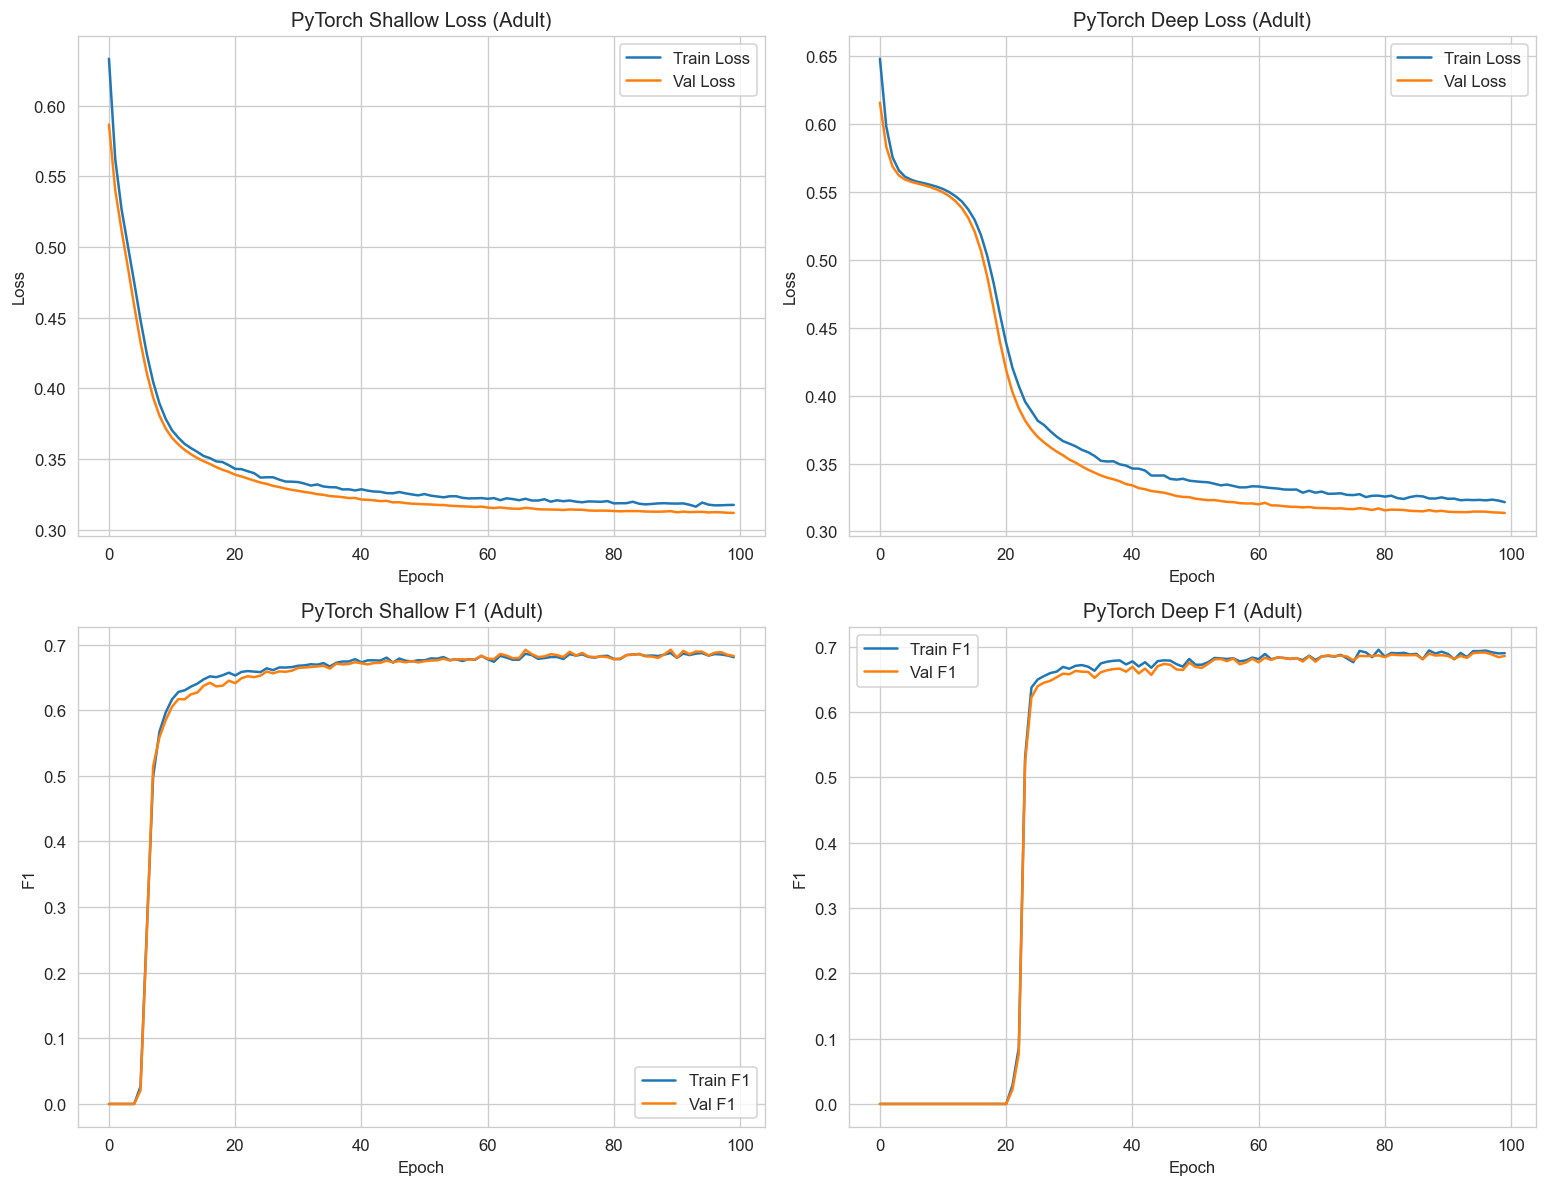

In [44]:
# PyTorch NN Adult — Epoch curves
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for i, (hist, name) in enumerate([(hist_shallow_a, 'Shallow'), (hist_deep_a, 'Deep')]):
    axes[0, i].plot(hist['train_loss'], label='Train Loss')
    axes[0, i].plot(hist['val_loss'], label='Val Loss')
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].set_ylabel('Loss')
    axes[0, i].set_title(f'PyTorch {name} Loss (Adult)')
    axes[0, i].legend()

    axes[1, i].plot(hist['train_metric'], label='Train F1')
    axes[1, i].plot(hist['val_metric'], label='Val F1')
    axes[1, i].set_xlabel('Epoch')
    axes[1, i].set_ylabel('F1')
    axes[1, i].set_title(f'PyTorch {name} F1 (Adult)')
    axes[1, i].legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}nn_pytorch_adult_epochs.png', bbox_inches='tight')
plt.show()

Shallow best val F1: 0.6922
Deep best val F1: 0.6912
NN-PyTorch (Shallow) Adult — Acc: 0.8507, F1: 0.6726


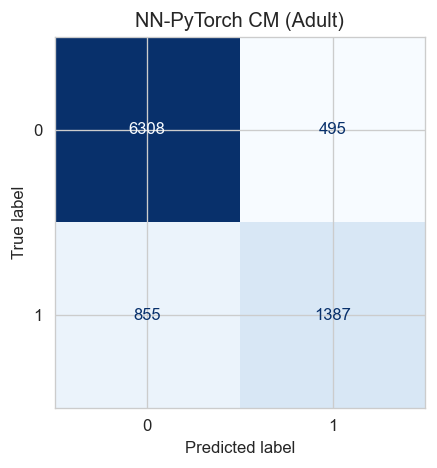

In [45]:
# PyTorch NN Adult — Evaluate (use better architecture)
# Pick the one with better val metric
best_val_shallow = max(hist_shallow_a['val_metric'])
best_val_deep = max(hist_deep_a['val_metric'])
print(f"Shallow best val F1: {best_val_shallow:.4f}")
print(f"Deep best val F1: {best_val_deep:.4f}")

best_pt_adult = deep_adult if best_val_deep >= best_val_shallow else shallow_adult
best_pt_name = 'Deep' if best_val_deep >= best_val_shallow else 'Shallow'

t0 = time.time()
y_pred_pt_adult = predict_pytorch(best_pt_adult, X_test_adult_proc, task='binary')
pt_pred_time_a = time.time() - t0

acc = accuracy_score(y_test_adult, y_pred_pt_adult)
f1 = f1_score(y_test_adult, y_pred_pt_adult)
fit_t = deep_fit_time_a if best_pt_name == 'Deep' else shallow_fit_time_a

results_adult.append({'model': 'NN-PyTorch', 'accuracy': acc, 'f1': f1,
                      'fit_time': fit_t, 'predict_time': pt_pred_time_a, 'y_pred': y_pred_pt_adult})
print(f"NN-PyTorch ({best_pt_name}) Adult — Acc: {acc:.4f}, F1: {f1:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion(y_test_adult, y_pred_pt_adult, f'NN-PyTorch CM (Adult)', ax=ax)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}nn_pytorch_adult_cm.png', bbox_inches='tight')
plt.show()

In [46]:
# ===== PyTorch NN - Wine =====
X_tr_w, X_val_w, y_tr_w, y_val_w = tts(
    X_train_wine_proc, y_train_wine, test_size=0.15, random_state=SEED, stratify=y_train_wine
)

input_dim_wine = X_train_wine_proc.shape[1]
n_classes_wine = len(wine_label_map)

shallow_wine = PytorchMLP(input_dim_wine, [128, 128], n_classes_wine, activation='relu', dropout=0.2)
deep_wine = PytorchMLP(input_dim_wine, [64, 64, 64, 64], n_classes_wine, activation='relu', dropout=0.2)

print(f"Shallow params: {shallow_wine.count_params()}")
print(f"Deep params: {deep_wine.count_params()}")

t0 = time.time()
shallow_wine, hist_shallow_w = train_pytorch_mlp(
    shallow_wine, X_tr_w, y_tr_w, X_val_w, y_val_w,
    lr=0.01, weight_decay=1e-4, batch_size=128, max_epochs=100, patience=15, task='multiclass'
)
shallow_fit_time_w = time.time() - t0

t0 = time.time()
deep_wine, hist_deep_w = train_pytorch_mlp(
    deep_wine, X_tr_w, y_tr_w, X_val_w, y_val_w,
    lr=0.01, weight_decay=1e-4, batch_size=128, max_epochs=100, patience=15, task='multiclass'
)
deep_fit_time_w = time.time() - t0

print(f"Shallow trained {len(hist_shallow_w['train_loss'])} epochs in {shallow_fit_time_w:.1f}s")
print(f"Deep trained {len(hist_deep_w['train_loss'])} epochs in {deep_fit_time_w:.1f}s")

Shallow params: 19208
Deep params: 13832


Shallow trained 100 epochs in 2.7s
Deep trained 100 epochs in 3.8s


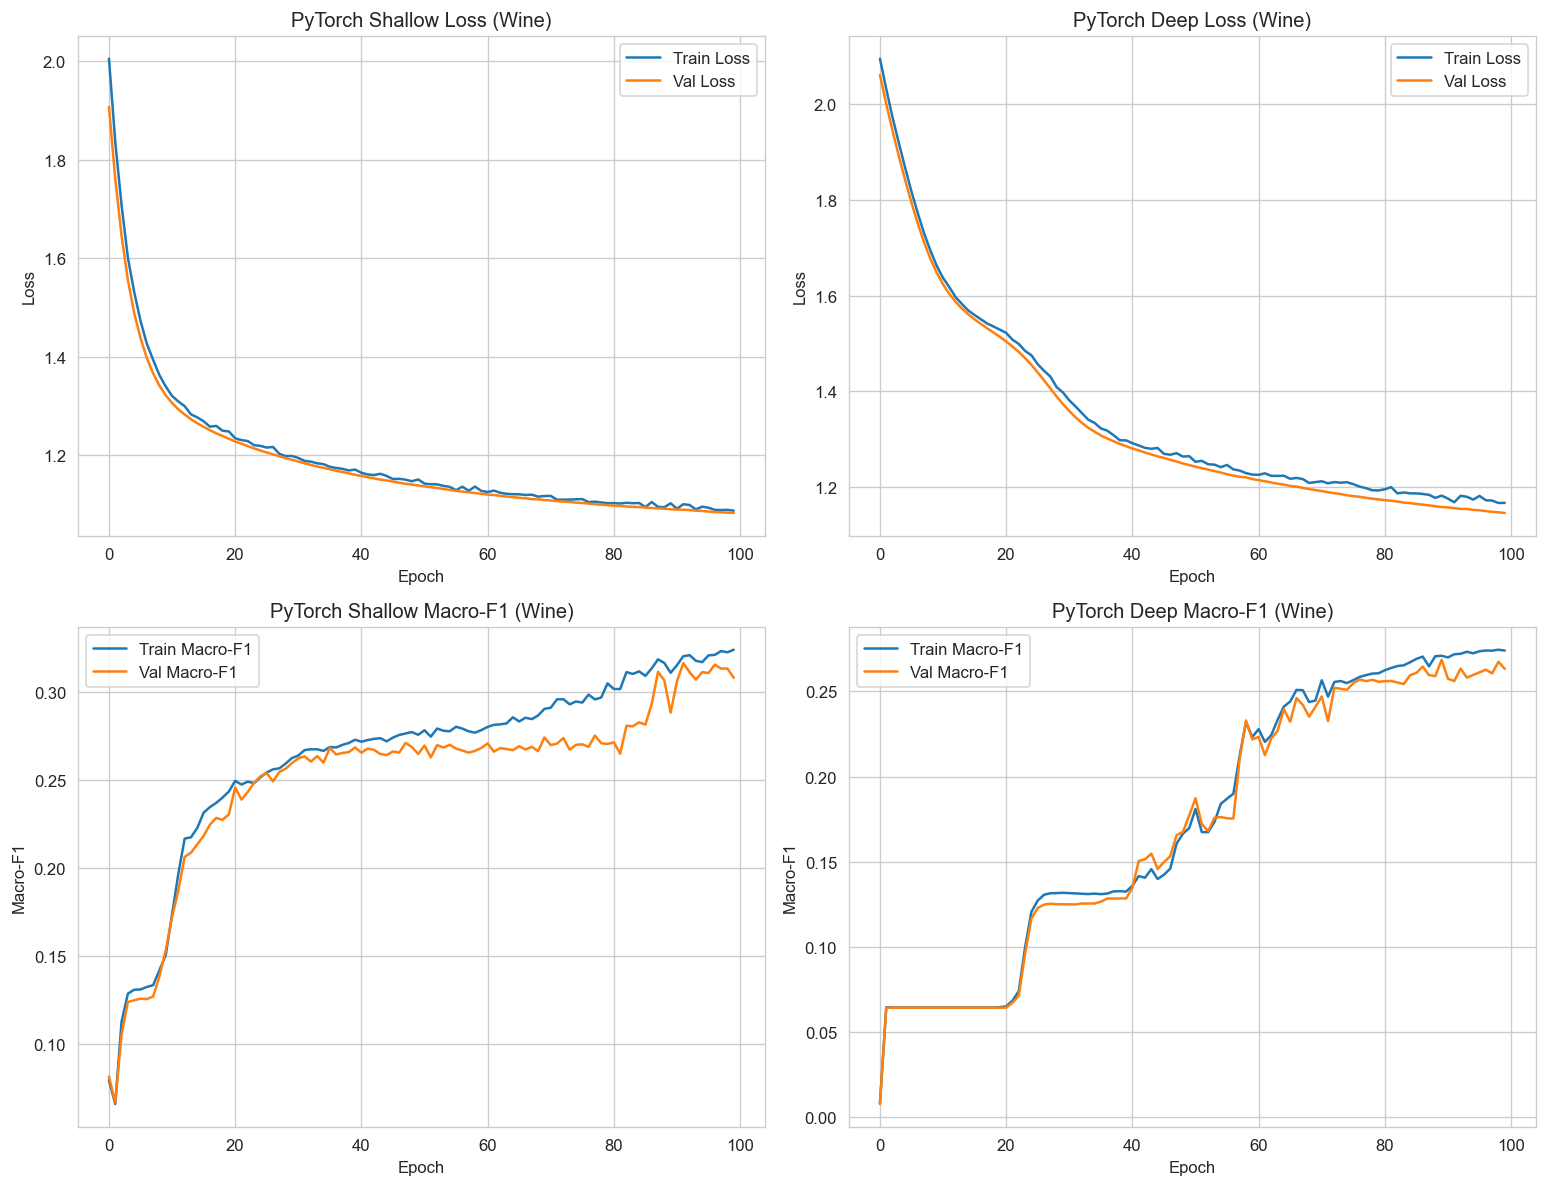

In [47]:
# PyTorch NN Wine — Epoch curves
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for i, (hist, name) in enumerate([(hist_shallow_w, 'Shallow'), (hist_deep_w, 'Deep')]):
    axes[0, i].plot(hist['train_loss'], label='Train Loss')
    axes[0, i].plot(hist['val_loss'], label='Val Loss')
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].set_ylabel('Loss')
    axes[0, i].set_title(f'PyTorch {name} Loss (Wine)')
    axes[0, i].legend()

    axes[1, i].plot(hist['train_metric'], label='Train Macro-F1')
    axes[1, i].plot(hist['val_metric'], label='Val Macro-F1')
    axes[1, i].set_xlabel('Epoch')
    axes[1, i].set_ylabel('Macro-F1')
    axes[1, i].set_title(f'PyTorch {name} Macro-F1 (Wine)')
    axes[1, i].legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}nn_pytorch_wine_epochs.png', bbox_inches='tight')
plt.show()

Shallow best val Macro-F1: 0.3164
Deep best val Macro-F1: 0.2686
NN-PyTorch (Shallow) Wine — Acc: 0.5638, F1(macro): 0.3085


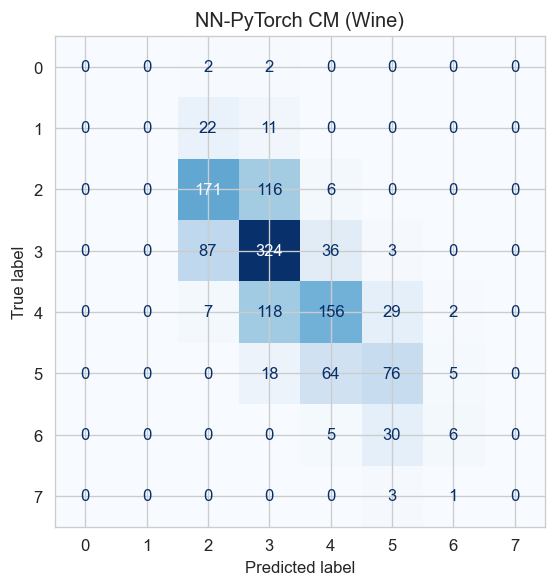

In [48]:
# PyTorch NN Wine — Evaluate
best_val_shallow_w = max(hist_shallow_w['val_metric'])
best_val_deep_w = max(hist_deep_w['val_metric'])
print(f"Shallow best val Macro-F1: {best_val_shallow_w:.4f}")
print(f"Deep best val Macro-F1: {best_val_deep_w:.4f}")

best_pt_wine = deep_wine if best_val_deep_w >= best_val_shallow_w else shallow_wine
best_pt_name_w = 'Deep' if best_val_deep_w >= best_val_shallow_w else 'Shallow'

t0 = time.time()
y_pred_pt_wine = predict_pytorch(best_pt_wine, X_test_wine_proc, task='multiclass')
pt_pred_time_w = time.time() - t0

acc = accuracy_score(y_test_wine, y_pred_pt_wine)
f1 = f1_score(y_test_wine, y_pred_pt_wine, average='macro')
fit_t = deep_fit_time_w if best_pt_name_w == 'Deep' else shallow_fit_time_w

results_wine.append({'model': 'NN-PyTorch', 'accuracy': acc, 'f1': f1,
                     'fit_time': fit_t, 'predict_time': pt_pred_time_w, 'y_pred': y_pred_pt_wine})
print(f"NN-PyTorch ({best_pt_name_w}) Wine — Acc: {acc:.4f}, F1(macro): {f1:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion(y_test_wine, y_pred_pt_wine, f'NN-PyTorch CM (Wine)', ax=ax,
               labels=list(range(len(wine_label_map))))
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}nn_pytorch_wine_cm.png', bbox_inches='tight')
plt.show()

---
# 9. NN Comparison: scikit-learn vs PyTorch

In [49]:
# Side-by-side comparison table
print("=" * 70)
print("Neural Network Comparison: scikit-learn vs PyTorch")
print("=" * 70)

for ds_name, res_list in [("Adult", results_adult), ("Wine", results_wine)]:
    sk = [r for r in res_list if r['model'] == 'NN-sklearn'][0]
    pt = [r for r in res_list if r['model'] == 'NN-PyTorch'][0]
    metric_name = 'F1' if ds_name == 'Adult' else 'Macro-F1'

    print(f"\n--- {ds_name} ---")
    print(f"{'Metric':<20} {'sklearn':>12} {'PyTorch':>12}")
    print(f"{'Accuracy':<20} {sk['accuracy']:>12.4f} {pt['accuracy']:>12.4f}")
    print(f"{metric_name:<20} {sk['f1']:>12.4f} {pt['f1']:>12.4f}")
    print(f"{'Fit time (s)':<20} {sk['fit_time']:>12.3f} {pt['fit_time']:>12.3f}")
    print(f"{'Predict time (s)':<20} {sk['predict_time']:>12.3f} {pt['predict_time']:>12.3f}")

Neural Network Comparison: scikit-learn vs PyTorch

--- Adult ---
Metric                    sklearn      PyTorch
Accuracy                   0.8503       0.8507
F1                         0.6805       0.6726
Fit time (s)              125.372       31.082
Predict time (s)            0.016        0.005

--- Wine ---
Metric                    sklearn      PyTorch
Accuracy                   0.5346       0.5638
Macro-F1                   0.2846       0.3085
Fit time (s)                1.730        2.683
Predict time (s)            0.039        0.002


---
# 10. Extra Credit: Activation Function Study (Adult, PyTorch, SGD)

In [50]:
# Compare ReLU, GELU, SiLU, Tanh on Adult dataset
# Same architecture, preprocessing, regularization, SGD only
activations = ['relu', 'gelu', 'silu', 'tanh']
act_histories = {}
act_results = {}

# Use the deep architecture for consistency
arch = [100, 100, 100, 100]

for act in activations:
    print(f"Training with activation: {act}")
    torch.manual_seed(SEED)
    model = PytorchMLP(input_dim_adult, arch, 1, activation=act, dropout=0.2)
    model, hist = train_pytorch_mlp(
        model, X_tr_a, y_tr_a, X_val_a, y_val_a,
        lr=0.01, weight_decay=1e-4, batch_size=256, max_epochs=100, patience=15, task='binary'
    )
    act_histories[act] = hist

    y_pred = predict_pytorch(model, X_test_adult_proc, task='binary')
    act_results[act] = {
        'accuracy': accuracy_score(y_test_adult, y_pred),
        'f1': f1_score(y_test_adult, y_pred),
        'best_val_f1': max(hist['val_metric']),
        'epochs': len(hist['train_loss'])
    }
    print(f"  {act}: Acc={act_results[act]['accuracy']:.4f}, F1={act_results[act]['f1']:.4f}, "
          f"Epochs={act_results[act]['epochs']}")

print("\nActivation study complete.")

Training with activation: relu


  relu: Acc=0.8506, F1=0.6822, Epochs=100
Training with activation: gelu


  gelu: Acc=0.8355, F1=0.6271, Epochs=100
Training with activation: silu


  silu: Acc=0.8286, F1=0.5993, Epochs=100
Training with activation: tanh


  tanh: Acc=0.8458, F1=0.6560, Epochs=100

Activation study complete.


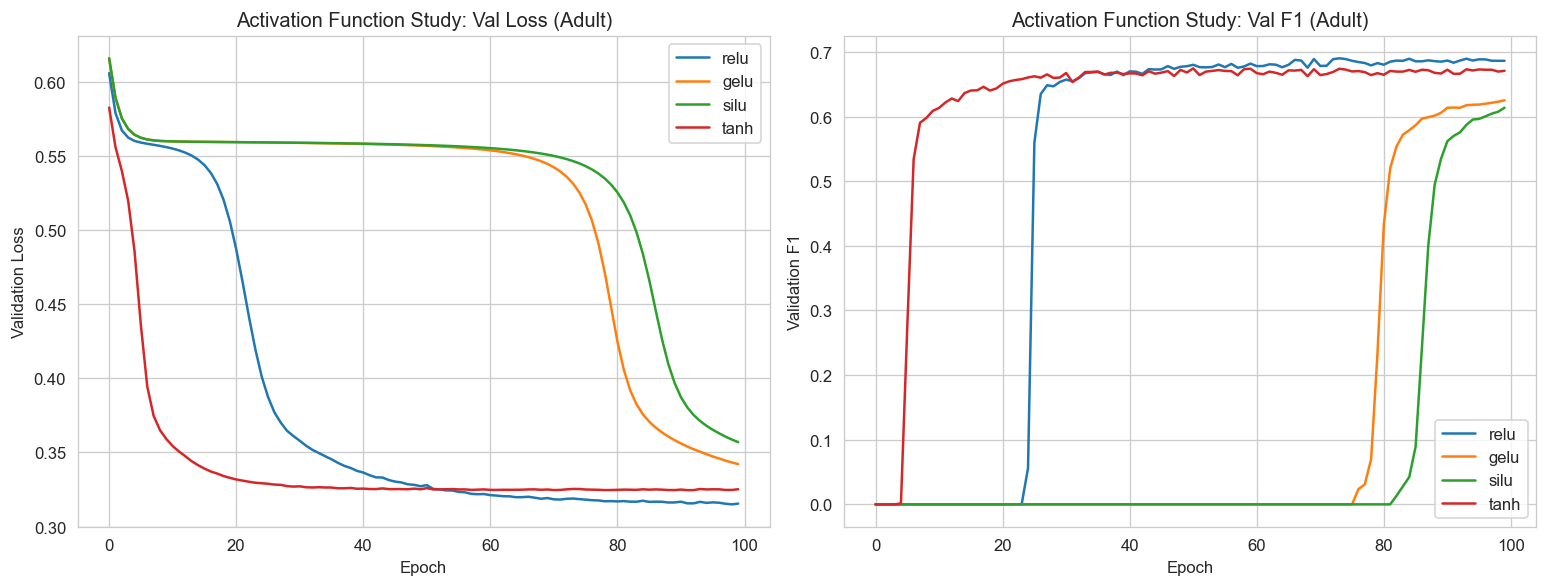


Activation Function Comparison (Adult)
Activation     Test Acc    Test F1  Best Val F1   Epochs
relu             0.8506     0.6822       0.6902      100
gelu             0.8355     0.6271       0.6253      100
silu             0.8286     0.5993       0.6137      100
tanh             0.8458     0.6560       0.6745      100


In [51]:
# Extra credit — Epoch-wise validation curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for act in activations:
    h = act_histories[act]
    axes[0].plot(h['val_loss'], label=act)
    axes[1].plot(h['val_metric'], label=act)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Activation Function Study: Val Loss (Adult)')
axes[0].legend()

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation F1')
axes[1].set_title('Activation Function Study: Val F1 (Adult)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}extra_credit_activations.png', bbox_inches='tight')
plt.show()

# Comparison table
print("\nActivation Function Comparison (Adult)")
print(f"{'Activation':<12} {'Test Acc':>10} {'Test F1':>10} {'Best Val F1':>12} {'Epochs':>8}")
for act in activations:
    r = act_results[act]
    print(f"{act:<12} {r['accuracy']:>10.4f} {r['f1']:>10.4f} {r['best_val_f1']:>12.4f} {r['epochs']:>8}")

---
# 11. Cross-Model Comparison

In [52]:
# Summary tables
for ds_name, res_list in [("Adult", results_adult), ("Wine", results_wine)]:
    metric_name = 'F1' if ds_name == 'Adult' else 'Macro-F1'
    print(f"\n{'='*60}")
    print(f"Cross-Model Comparison: {ds_name}")
    print(f"{'='*60}")
    print(f"{'Model':<15} {'Accuracy':>10} {metric_name:>10} {'Fit(s)':>10} {'Pred(s)':>10}")
    for r in res_list:
        print(f"{r['model']:<15} {r['accuracy']:>10.4f} {r['f1']:>10.4f} "
              f"{r['fit_time']:>10.3f} {r['predict_time']:>10.3f}")


Cross-Model Comparison: Adult
Model             Accuracy         F1     Fit(s)    Pred(s)
DT                  0.8541     0.6695      0.162      0.001
kNN                 0.8357     0.6424      0.001      0.796
SVM-Linear          0.8457     0.6543      0.114      0.000
SVM-RBF             0.8475     0.6496      1.353      2.393
NN-sklearn          0.8503     0.6805    125.372      0.016
NN-PyTorch          0.8507     0.6726     31.082      0.005

Cross-Model Comparison: Wine
Model             Accuracy   Macro-F1     Fit(s)    Pred(s)
DT                  0.6092     0.4321      0.021      0.000
kNN                 0.6785     0.4548      0.001      0.043
SVM-Linear          0.5177     0.2526      0.027      0.000
SVM-RBF             0.6615     0.4665      0.480      0.145
NN-sklearn          0.5346     0.2846      1.730      0.039
NN-PyTorch          0.5638     0.3085      2.683      0.002


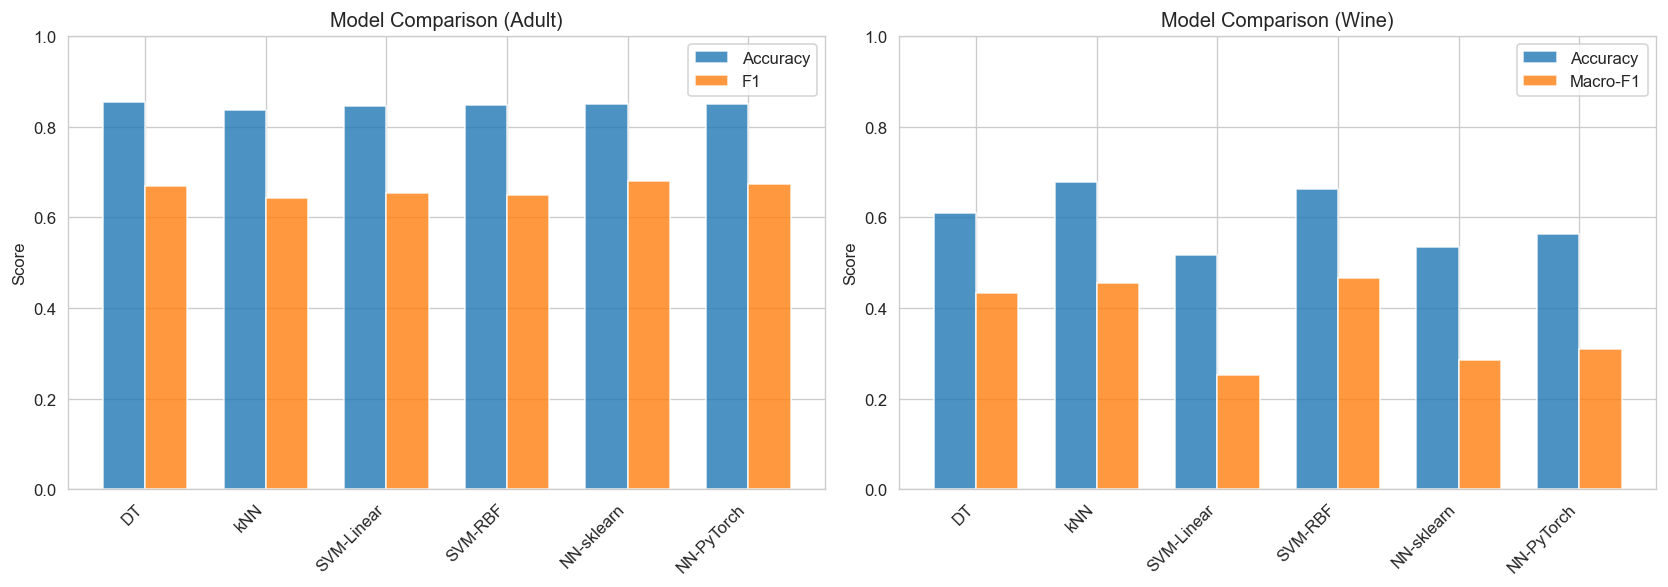

In [53]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (ds_name, res_list) in enumerate([("Adult", results_adult), ("Wine", results_wine)]):
    models = [r['model'] for r in res_list]
    f1s = [r['f1'] for r in res_list]
    accs = [r['accuracy'] for r in res_list]

    x = np.arange(len(models))
    w = 0.35
    axes[i].bar(x - w/2, accs, w, label='Accuracy', alpha=0.8)
    axes[i].bar(x + w/2, f1s, w, label='F1' if ds_name == 'Adult' else 'Macro-F1', alpha=0.8)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(models, rotation=45, ha='right')
    axes[i].set_ylabel('Score')
    axes[i].set_title(f'Model Comparison ({ds_name})')
    axes[i].legend()
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}cross_model_comparison.png', bbox_inches='tight')
plt.show()

---
# 12. Leakage / Evaluation Debug

In [54]:
# Dummy baseline + shuffled-label baseline
for ds_name, X_tr, y_tr, X_te, y_te in [
    ("Adult", X_train_adult_proc, y_train_adult, X_test_adult_proc, y_test_adult),
    ("Wine", X_train_wine_proc, y_train_wine, X_test_wine_proc, y_test_wine)
]:
    avg = 'binary' if ds_name == 'Adult' else 'macro'
    print(f"\n--- {ds_name} Sanity Checks ---")

    # Dummy (most frequent)
    dummy = DummyClassifier(strategy='most_frequent')
    dummy.fit(X_tr, y_tr)
    y_dum = dummy.predict(X_te)
    print(f"Dummy (most_frequent): Acc={accuracy_score(y_te, y_dum):.4f}, "
          f"F1={f1_score(y_te, y_dum, average=avg, zero_division=0):.4f}")

    # Shuffled labels
    y_shuf = np.random.RandomState(SEED).permutation(y_tr)
    from sklearn.tree import DecisionTreeClassifier as DTC
    dt_shuf = DTC(max_depth=10, random_state=SEED)
    dt_shuf.fit(X_tr, y_shuf)
    y_pred_shuf = dt_shuf.predict(X_te)
    print(f"Shuffled-label DT:    Acc={accuracy_score(y_te, y_pred_shuf):.4f}, "
          f"F1={f1_score(y_te, y_pred_shuf, average=avg, zero_division=0):.4f}")

    # Best model performance for comparison
    best = max([r for r in (results_adult if ds_name == 'Adult' else results_wine)],
               key=lambda r: r['f1'])
    print(f"Best model ({best['model']}): Acc={best['accuracy']:.4f}, F1={best['f1']:.4f}")


--- Adult Sanity Checks ---
Dummy (most_frequent): Acc=0.7521, F1=0.0000


Shuffled-label DT:    Acc=0.7498, F1=0.0341
Best model (NN-sklearn): Acc=0.8503, F1=0.6805

--- Wine Sanity Checks ---
Dummy (most_frequent): Acc=0.3462, F1=0.0643
Shuffled-label DT:    Acc=0.3223, F1=0.1134
Best model (SVM-RBF): Acc=0.6615, F1=0.4665


---
# 13. Hardware & Reproducibility Notes

In [55]:
import platform
print(f"Platform: {platform.platform()}")
print(f"Python: {platform.python_version()}")
print(f"CPU: {platform.processor()}")
print(f"Random seed: {SEED}")
print(f"Train/test split: 80/20 stratified")
print(f"CV: Stratified 5-fold")

import sklearn, torch
print(f"scikit-learn: {sklearn.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print()
print("CV Note: DT and kNN were tuned with 5-fold CV. RBF SVM and NN used")
print("3-fold CV to reduce runtime. This may yield slightly noisier HP selection")
print("for expensive models, but final comparison is fair — all models are")
print("evaluated on the same held-out test set.")

Platform: macOS-15.7.3-arm64-arm-64bit
Python: 3.11.3
CPU: arm
Random seed: 42
Train/test split: 80/20 stratified
CV: Stratified 5-fold
scikit-learn: 1.3.2
PyTorch: 2.1.2
NumPy: 1.26.2
Pandas: 2.2.1

CV Note: DT and kNN were tuned with 5-fold CV. RBF SVM and NN used
3-fold CV to reduce runtime. This may yield slightly noisier HP selection
for expensive models, but final comparison is fair — all models are
evaluated on the same held-out test set.


---
# 14. Conclusion Notes (for report)

**Next steps to explore:**
- Class rebalancing techniques (SMOTE, oversampling, undersampling, or class_weight adjustments) to improve minority-class performance, particularly on Adult (3:1 imbalance) and Wine (rare quality ratings 1, 2, 7, 8).
- Feature selection or dimensionality reduction to address the high-dimensional one-hot encoded space in Adult.
- Ensemble methods (Random Forest, Gradient Boosting) as natural extensions of the single Decision Tree.


In [56]:
elapsed = time.time() - _notebook_start
print(f"Total notebook runtime: {elapsed/60:.1f} minutes ({elapsed:.0f} seconds)")

Total notebook runtime: 22.6 minutes (1355 seconds)
